# **Trabajo Práctico N°2: Predicción de lluvia en Australia**


### Contexto del problema


El objetivo del trabajo práctico es desarrollar un modelo de clasificación capaz de predecir si lloverá o no al día siguiente en distintas ciudades de Australia.

El dataset utilizado contiene información meteorológica histórica, incluyendo variables climáticas como temperatura, humedad, presión atmosférica, velocidad del viento, nubosidad y precipitaciones, entre otras. Podemos encontrar variables de tipo numericas (temperatura, presión, humedad, velocidad del viento), categoricas (dirección del viento, ubicación y lluvia (yes/no)) y variables temporales (date)

La variable objetivo del problema es "RainTomorrow" es de tipo categórica (Yes (1) → va a llover / No (0) → no va a llover) e indica si lloverá o no al día siguiente.


Variables del Dataset

- **Date**: fecha de la observación meteorológica.
- **Location**: ciudad donde se registraron los datos.
- **Unnamed: 0**: índice del dataset

---

Temperatura

- **MinTemp**: temperatura mínima del día (°C).
- **MaxTemp**: temperatura máxima del día (°C).
- **Temp9am**: temperatura registrada a las 9 AM.
- **Temp3pm**: temperatura registrada a las 3 PM.

---

Lluvia

- **Rainfall**: cantidad de lluvia registrada en el día (mm).
- **RainToday**: indica si llovió en el día actual (Yes/No).
- **RainTomorrow**: variable objetivo que indica si lloverá al día siguiente (Yes/No).
- **RainfallTomorrow**: cantidad de lluvia del día siguiente

---

Viento

- **WindGustDir**: dirección de la ráfaga de viento más intensa.
- **WindGustSpeed**: velocidad máxima del viento (km/h).
- **WindDir9am**: dirección del viento a las 9 AM.
- **WindDir3pm**: dirección del viento a las 3 PM.
- **WindSpeed9am**: velocidad del viento a las 9 AM.
- **WindSpeed3pm**: velocidad del viento a las 3 PM.

---

Humedad

- **Humidity9am**: humedad relativa a las 9 AM (%).
- **Humidity3pm**: humedad relativa a las 3 PM (%).

---

Presión

- **Pressure9am**: presión atmosférica a las 9 AM (hPa).
- **Pressure3pm**: presión atmosférica a las 3 PM (hPa).

---

Nubosidad

- **Cloud9am**: nivel de nubosidad a las 9 AM (escala de 0 a 8).
- **Cloud3pm**: nivel de nubosidad a las 3 PM (escala de 0 a 8).

---

- **Sunshine**: cantidad de horas de sol durante el día.
- **Evaporation**: nivel de evaporación (mm).

---


### Importación de librerias y dataset


In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split,GridSearchCV, StratifiedKFold,RandomizedSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report,roc_curve, roc_auc_score)
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, cohen_kappa_score
import optuna
import shap
import joblib
import os
import json
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from pycaret.classification import *
from tensorflow import keras
from tensorflow.keras import layers

In [132]:
df_original = pd.read_csv("weatherAUS_2026C1.csv",sep=",")
df = df_original.copy()
print(f"{df.shape[0]} filas, {df.shape[1]} columnas")

145412 filas, 25 columnas


In [133]:
len(df)

145412

# **EJERCICIO 1**


### Análisis Descriptivo


In [134]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

In [135]:
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


### Transformación de variables


In [136]:
#transformamos RainToday y RainTomorrow a numerico
#RainTomorrow es: yes=1 llueve, No=0 no llueve
df["RainToday"] = df["RainToday"].map({"Yes": 1, "No": 0})

#RainToday es binaria con el mismo criterio
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

En Australia las estaciones son inversas al hemisferio norte:

Verano: dic, ene, feb / Otoño: mar, abr, may / Invierno: jun, jul, ago / Primavera: sep, oct, nov

Esto captura la estacionalidad sin agregar ruido de día/mes exacto


In [137]:
#transformar Date en estación del año
#usamos errors='coerce' para convertir valores mal formateados
#eliminamos esas filas ya que no aportan información temporal válida.
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

#verificamos cuántos valores inválidos había
nulos_fecha = df["Date"].isnull().sum()
print(f"Fechas inválidas encontradas y eliminadas: {nulos_fecha}")
df = df.dropna(subset=["Date"])

df["Month"] = df["Date"].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df["Season"] = df["Month"].apply(get_season)
df = df.drop(columns=["Date"])

print(df["Season"].value_counts())

Fechas inválidas encontradas y eliminadas: 0
Season
Autumn    38264
Winter    36689
Spring    35337
Summer    35122
Name: count, dtype: int64


### Visualizacion de datos


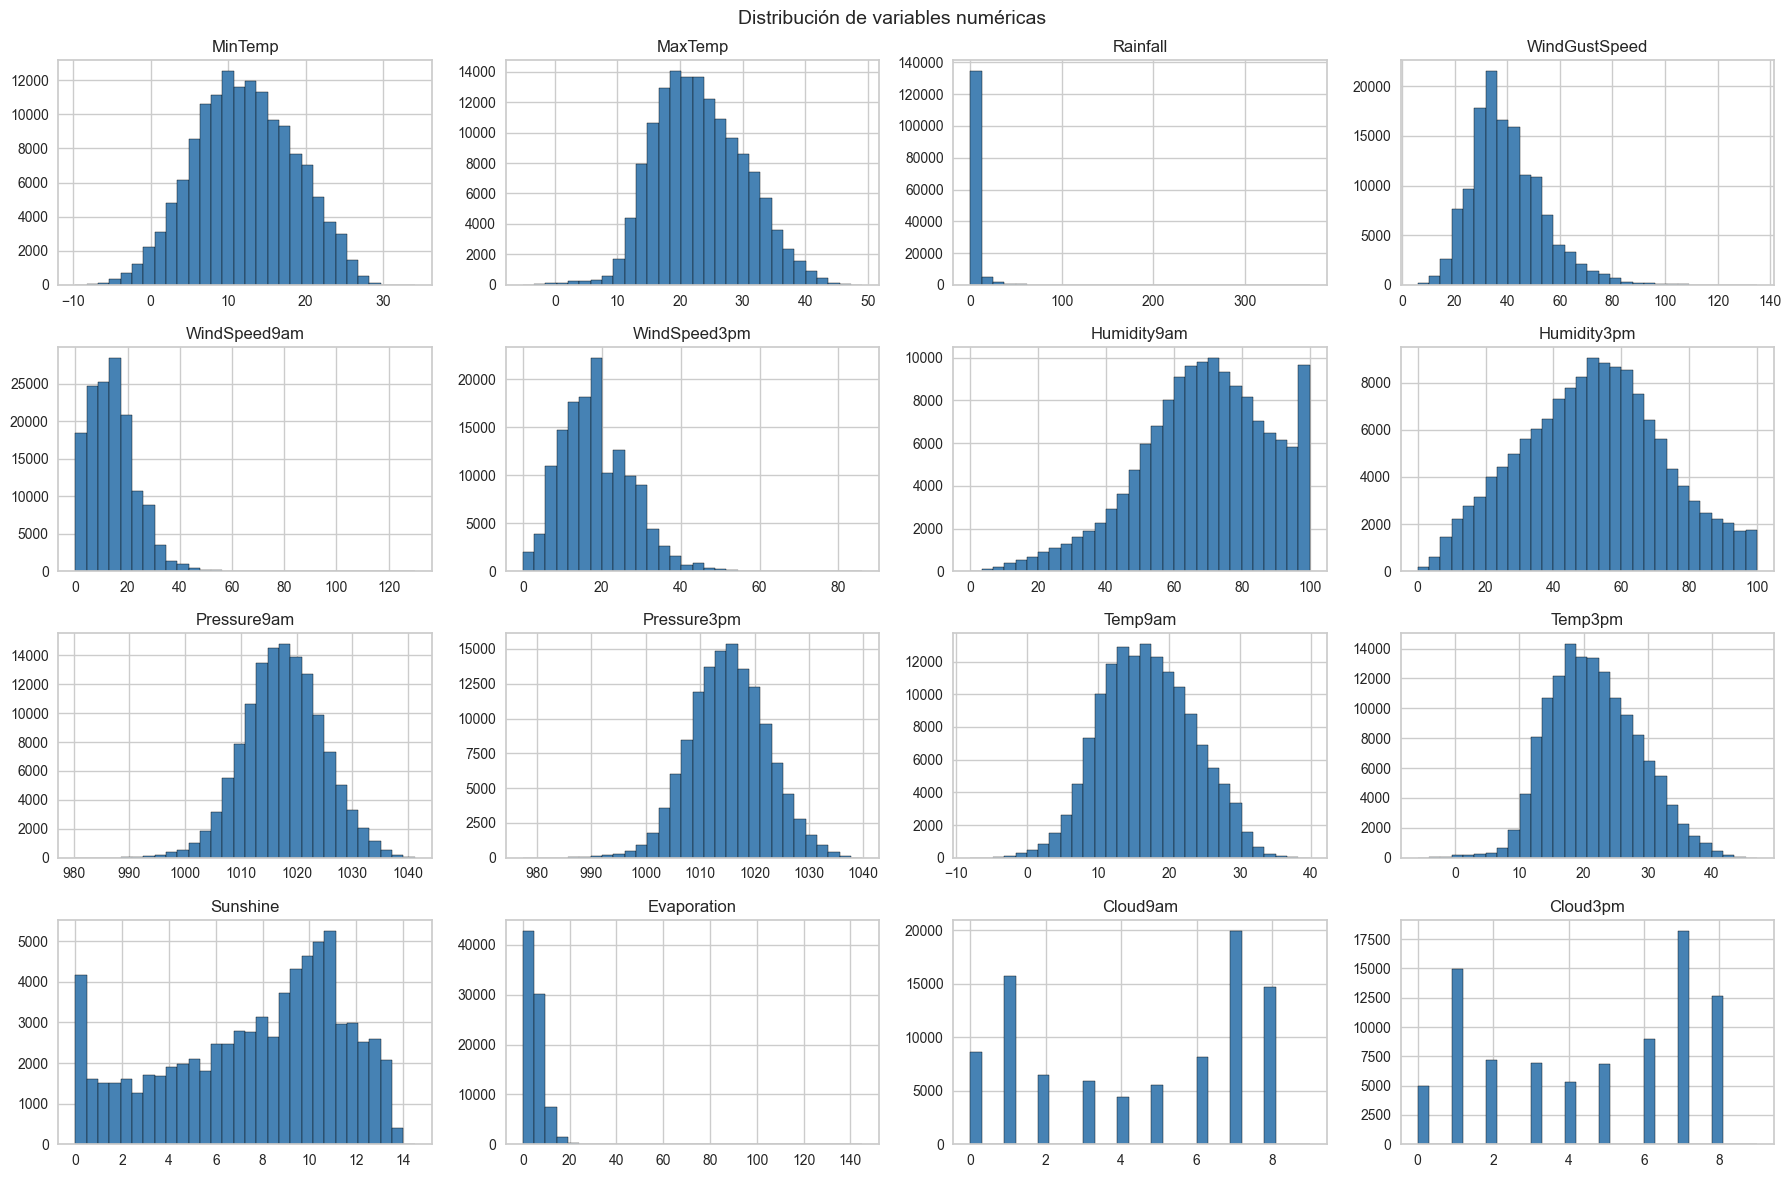

In [138]:
cols_num_plot = ["MinTemp", "MaxTemp", "Rainfall", "WindGustSpeed",
                 "WindSpeed9am", "WindSpeed3pm", "Humidity9am",
                 "Humidity3pm", "Pressure9am", "Pressure3pm",
                 "Temp9am", "Temp3pm", "Sunshine", "Evaporation",
                 "Cloud9am", "Cloud3pm"]

df[cols_num_plot].hist(bins=30, figsize=(18, 12), color="steelblue", edgecolor="black")

plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Las variables numéricas presentan comportamientos diversos. Las temperaturas (MinTemp, MaxTemp, Temp9am y Temp3pm) muestran distribuciones aproximadamente normales, lo que indica estabilidad en sus valores y ausencia de grandes sesgos.

Por otro lado, variables como Rainfall y Evaporation presentan una fuerte asimetría positiva, con gran concentración de valores cercanos a cero y presencia de outliers extremos. Esto es consistente con fenómenos meteorológicos donde la mayoría de los días no llueve o la evaporación es baja.

Las variables de viento presentan distribuciones moderadamente sesgadas, mientras que la presión atmosférica muestra una distribución bastante normal y concentrada, indicando baja variabilidad.

En el caso de Sunshine, se observa una distribución dispersa, reflejando la variabilidad en la cantidad de horas de sol.

Finalmente, las variables Cloud9am y Cloud3pm presentan distribuciones discretas (valores enteros entre 0 y 8), con mayor concentración en valores medios y altos. Esto indica que la nubosidad es una variable categórica ordinal que captura distintos niveles de cobertura del cielo.


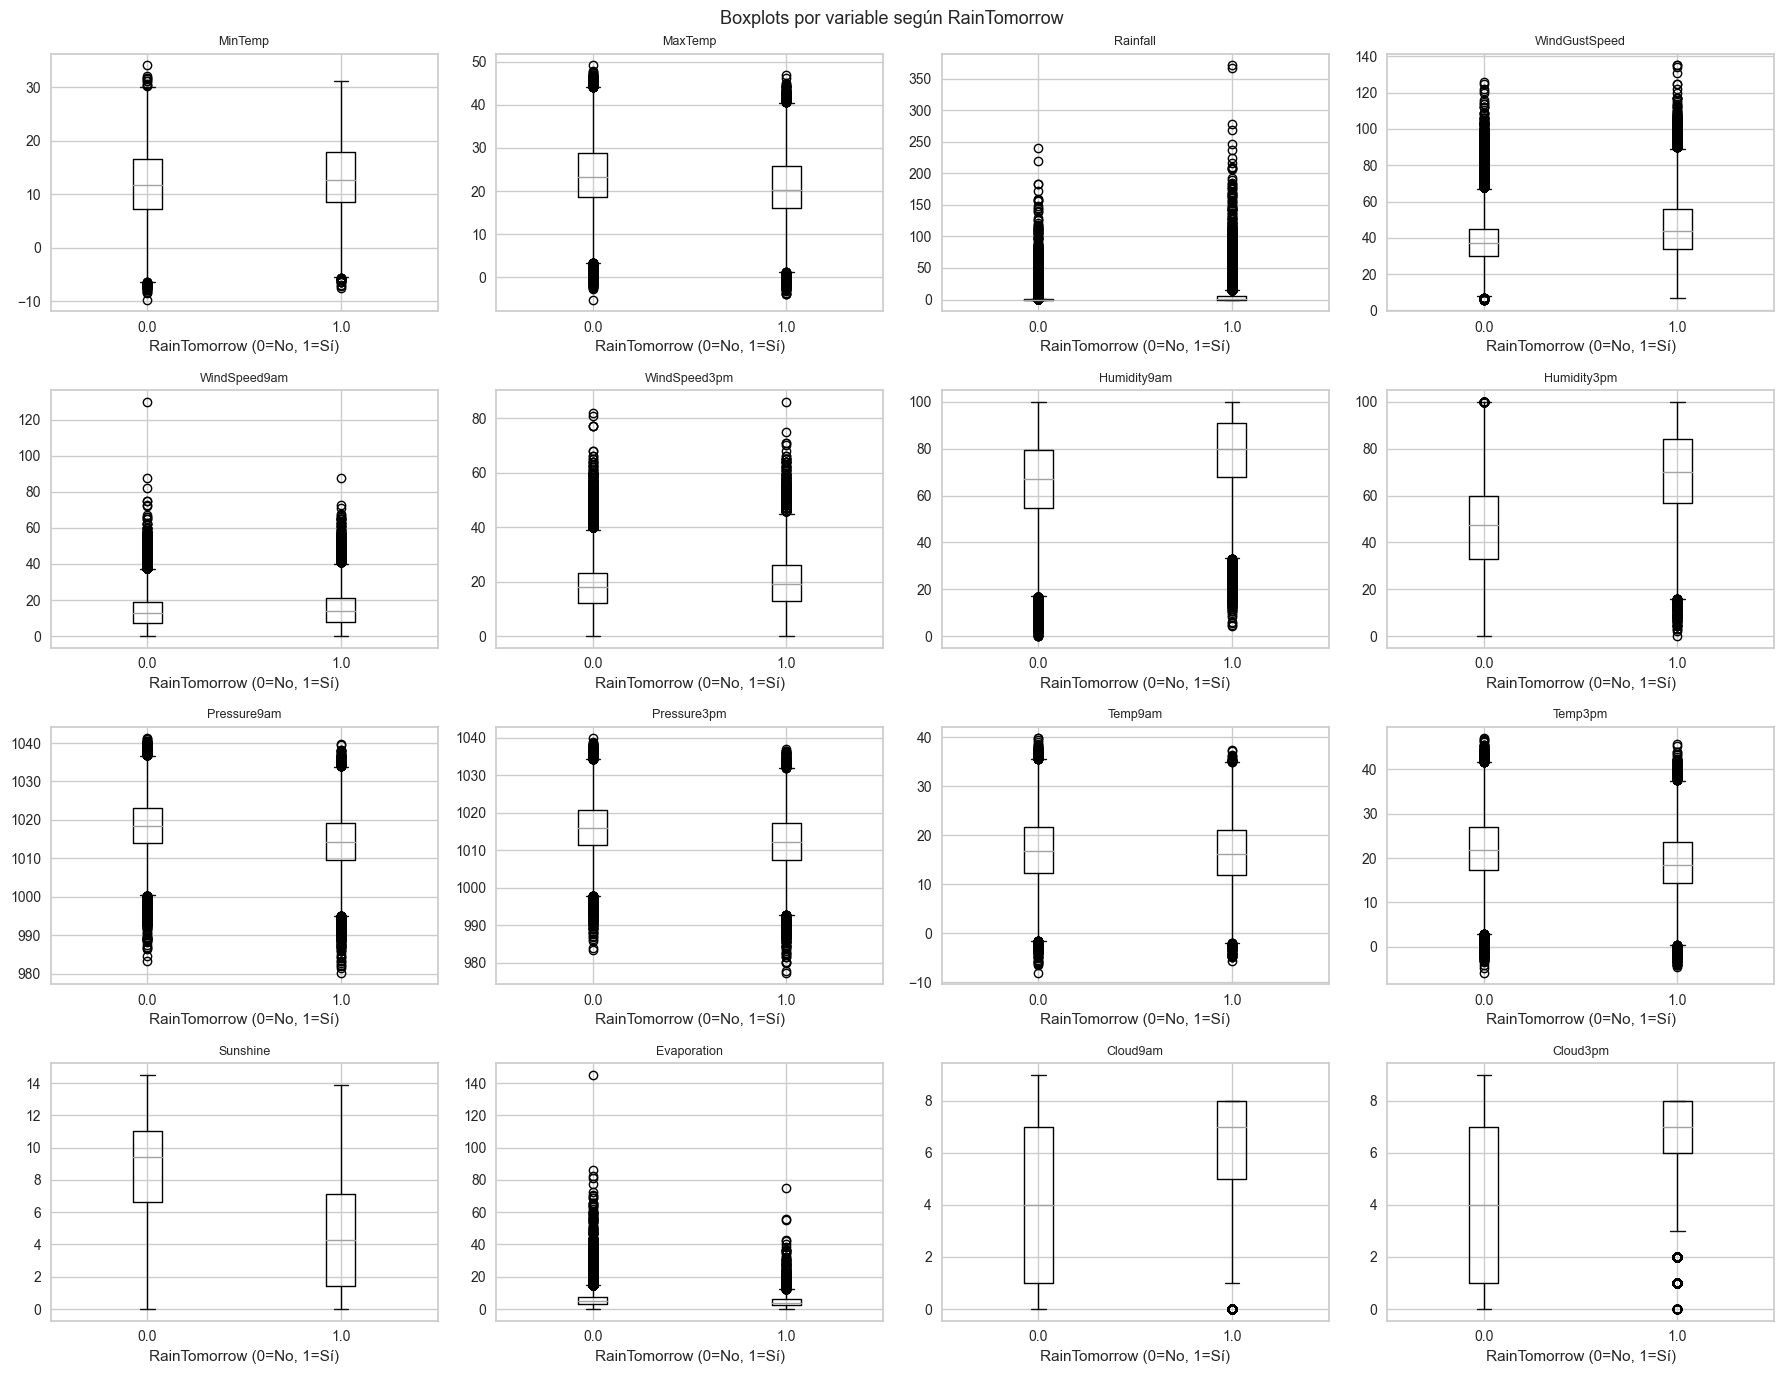

In [139]:
#comparamos la distribucion de cada variable segun si llovió o no para ver que variables se comportan diferente entre ambas clases
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_num_plot):
    df.boxplot(column=col, by="RainTomorrow", ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("RainTomorrow (0=No, 1=Sí)")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots por variable según RainTomorrow", fontsize=13)
plt.tight_layout()
plt.show()

El análisis de boxplots permite identificar qué variables diferencian mejor entre días con lluvia y sin lluvia.

Las variables más discriminantes son:

- Humidity3pm y Humidity9am: presentan valores significativamente más altos en días con lluvia.
- Cloud3pm y Cloud9am: muestran mayor nubosidad cuando llueve.
- Sunshine: presenta valores considerablemente más bajos en días con lluvia.
- Pressure9am y Pressure3pm: tienden a ser más bajas en días lluviosos.

Por otro lado, variables como temperatura (Temp9am, Temp3pm, MinTemp, MaxTemp) muestran diferencias menos marcadas entre clases, lo que sugiere menor poder predictivo.

También se observa la presencia de outliers en variables como Rainfall y WindGustSpeed, lo cual es esperable en datos climáticos y puede influir en el entrenamiento del modelo.


### Eliminación de variables


La variable `RainfallTomorrow` representa
la cantidad de lluvia registrada al día siguiente (en mm). Y como nuestra variable target es `RainTomorrow` (si llovió o no al día siguiente), detectamos **data leakage** ya que el modelo podría usar información del futuro para predecir, lo cual invalida cualquier resultado obtenido.
Por lo tanto en producción, a las 23:59hs no se dispone de ese dato, decidimos eliminarla del dataset.


In [140]:
#eliminamos columnas innecesarias
#Unnamed: 0: sin informacion
df = df.drop(columns=["Unnamed: 0", "RainfallTomorrow"])

In [141]:
#eliminamos filas sin target
df = df.dropna(subset=["RainTomorrow"])
print(f"Tras eliminar filas sin target: {df.shape}")

Tras eliminar filas sin target: (142153, 24)


In [142]:
n_original = len(df_original)
n_actual=len(df)
total_eliminados= n_original-n_actual
print(total_eliminados)

3259


### Correlacion entre variables


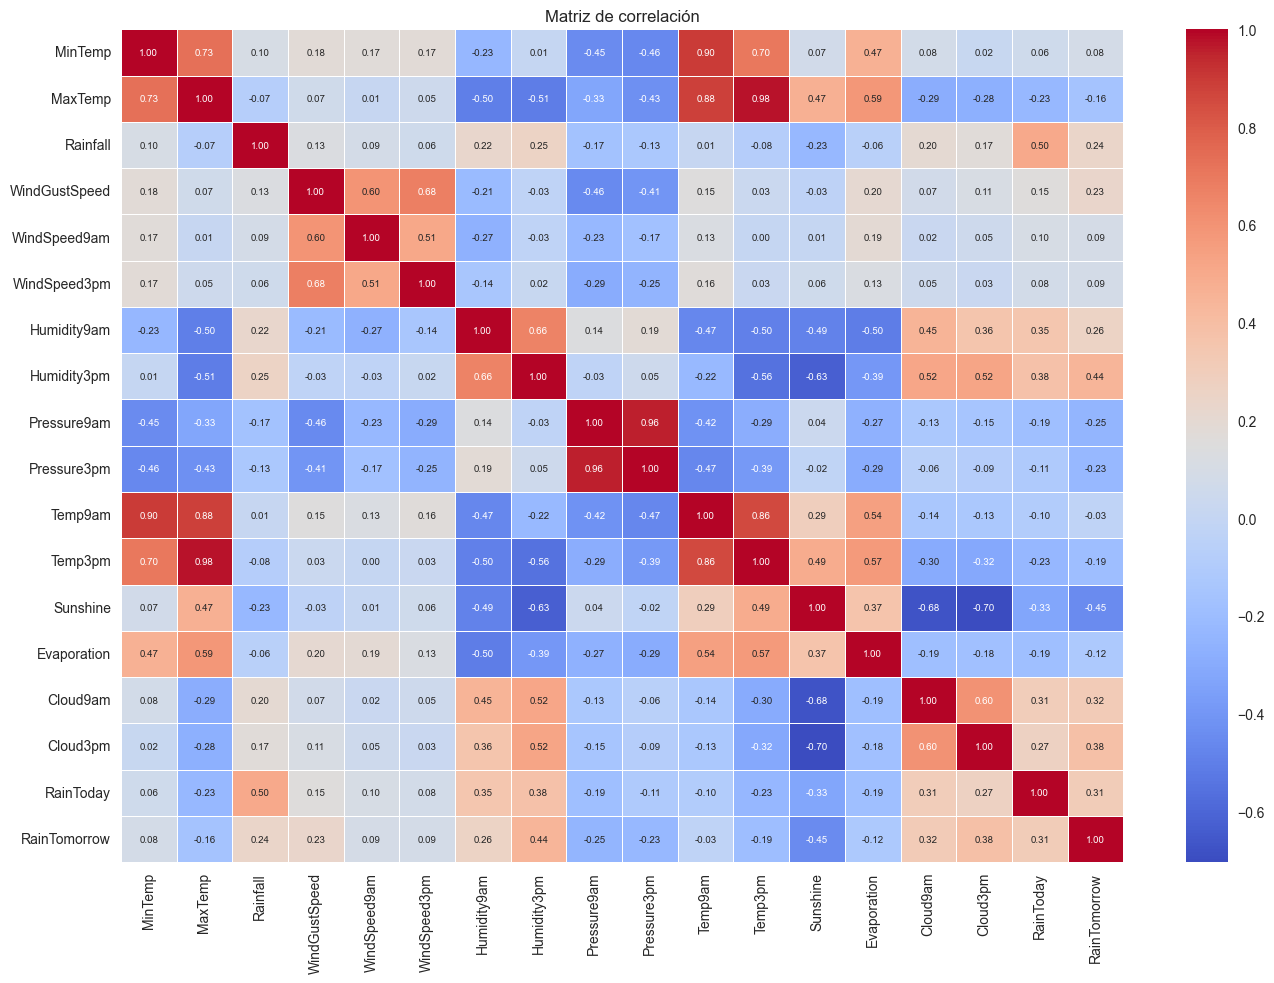

In [143]:
cols_corr = cols_num_plot + ["RainToday", "RainTomorrow"]

plt.figure(figsize=(14, 10))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 7})
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

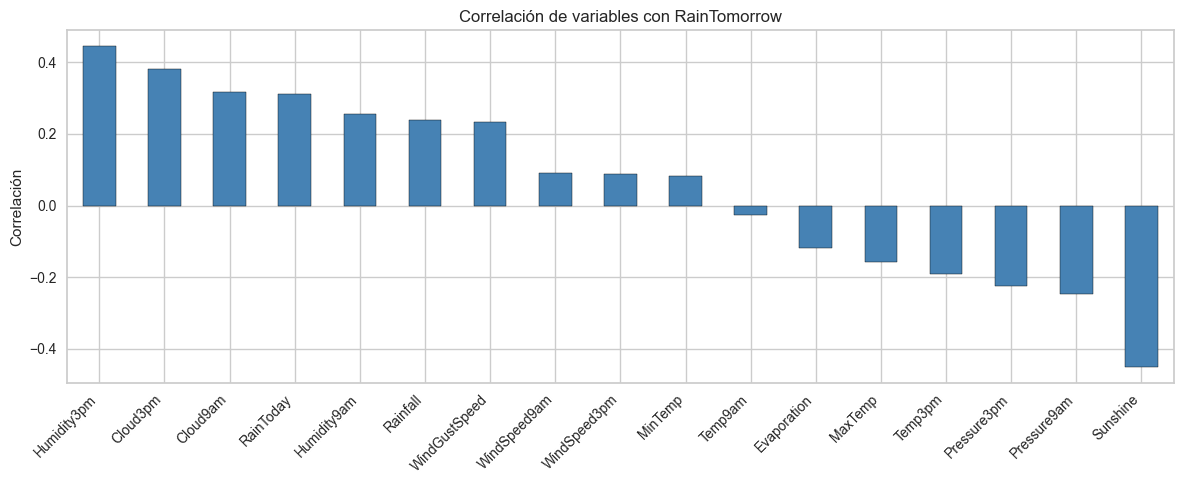

Humidity3pm      0.444945
Cloud3pm         0.381864
Cloud9am         0.317395
RainToday        0.313114
Humidity9am      0.256296
Rainfall         0.239035
WindGustSpeed    0.233473
WindSpeed9am     0.090138
WindSpeed3pm     0.087964
MinTemp          0.083777
Temp9am         -0.025383
Evaporation     -0.119315
MaxTemp         -0.158856
Temp3pm         -0.191944
Pressure3pm     -0.225758
Pressure9am     -0.246091
Sunshine        -0.450774
Name: RainTomorrow, dtype: float64


In [144]:
#correlacion con RainTomorrow, identificamos los mas y los menos relevantes
corr_target = df[cols_corr].corr()["RainTomorrow"].drop("RainTomorrow")
corr_target = corr_target.sort_values(ascending=False)

corr_target.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(12, 5))
plt.title("Correlación de variables con RainTomorrow")
plt.ylabel("Correlación")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(corr_target)

- **Humidity3pm (0.44)** es la variable más correlacionada con RainTomorrow,
  lo cual tiene sentido: alta humedad a las 3pm indica condiciones favorables para lluvia.
- **Cloud3pm y Cloud9am (~0.38-0.31)** confirman que mayor nubosidad predice lluvia.
- **RainToday (0.31)** también es relevante: si hoy llovió, es más probable que mañana llueva.
- **Sunshine (-0.45)** tiene correlación negativa fuerte: más horas de sol indican
  menos probabilidad de lluvia al día siguiente.
- **Pressure9am y Pressure3pm (~-0.24 - 0.22)** correlación negativa: menor presión
  atmosférica se asocia con sistemas de lluvia.
- Las variables de temperatura tienen correlación baja con el target.


### Verificamos nulos


In [145]:
missing = pd.DataFrame({
    "Faltantes": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().sum() / len(df) * 100).round(2)})
missing = missing[missing["Faltantes"] > 0].sort_values("Porcentaje (%)", ascending=False)
print(missing)

               Faltantes  Porcentaje (%)
Sunshine           67785           47.68
Evaporation        60812           42.78
Cloud3pm           57076           40.15
Cloud9am           53641           37.73
Pressure9am        14010            9.86
Pressure3pm        13977            9.83
WindDir9am         10009            7.04
WindGustDir         9328            6.56
WindGustSpeed       9268            6.52
WindDir3pm          3776            2.66
Humidity3pm         3609            2.54
Temp3pm             2725            1.92
WindSpeed3pm        2629            1.85
Humidity9am         1774            1.25
RainToday           1406            0.99
Rainfall            1406            0.99
WindSpeed9am        1348            0.95
Temp9am              904            0.64
MinTemp              637            0.45
MaxTemp              322            0.23


In [146]:
cols = ["Sunshine", "Humidity3pm", "Cloud3pm", "Cloud9am", "RainToday"] #variables mas importantes para la prediccion
filas_nulas = df[df[cols].isnull().all(axis=1)]
filas_nulas

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season
3384,BadgerysCreek,NaN,32.1,NaN,NaN,NaN,SSE,43.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12,Summer
3433,BadgerysCreek,19.5,27.5,NaN,NaN,NaN,NE,36.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1,Summer
3472,BadgerysCreek,12.6,21.6,NaN,NaN,NaN,S,32.0,SW,NaN,...,1021.8,NaN,NaN,NaN,18.7,NaN,NaN,0.0,3,Autumn
3530,BadgerysCreek,4.7,22.8,NaN,NaN,NaN,WSW,28.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5,Autumn
8842,Cobar,8.8,25.4,NaN,NaN,NaN,S,37.0,S,S,...,1016.9,1014.3,NaN,NaN,15.5,23.1,NaN,0.0,11,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143646,Katherine,NaN,37.5,NaN,NaN,NaN,NNE,49.0,ENE,E,...,1008.7,1003.6,NaN,NaN,NaN,NaN,NaN,0.0,12,Summer
143653,Katherine,NaN,37.3,NaN,NaN,NaN,N,38.0,E,N,...,1008.9,1004.3,NaN,NaN,NaN,NaN,NaN,0.0,12,Summer
143657,Katherine,NaN,34.4,NaN,NaN,NaN,W,44.0,WNW,W,...,1006.1,1001.8,NaN,NaN,NaN,NaN,NaN,1.0,12,Summer
143692,Katherine,NaN,36.6,NaN,NaN,NaN,NaN,NaN,NE,ENE,...,1008.3,1003.2,NaN,NaN,NaN,NaN,NaN,1.0,2,Summer


In [147]:
cols = ["Sunshine", "Humidity3pm", "Cloud3pm", "Cloud9am", "RainToday"]
df = df[~df[cols].isnull().all(axis=1)]

In [148]:
print(f"Filas sin info clave: {filas_nulas.shape[0]}")

Filas sin info clave: 94


In [149]:
n_original = len(df_original)
n_actual=len(df)

In [150]:
total_eliminados= n_original-n_actual
print(total_eliminados)

3353


Dado el alto porcentaje de valores faltantes, se eliminaron aquellas filas en las que todas las variables más relevantes para la predicción (según su correlación con la variable objetivo) estaban ausentes. Como dichas filas no contienen información útil para el modelo ya que ninguna de los registros poseen las variables relevantes decidimos eliminarlas ya que su imputación introduciría ruido.


### Chequeo dataset Desbalanceado


No llueve (0): 110233 (77.6%)
Llueve   (1): 31826 (22.4%)


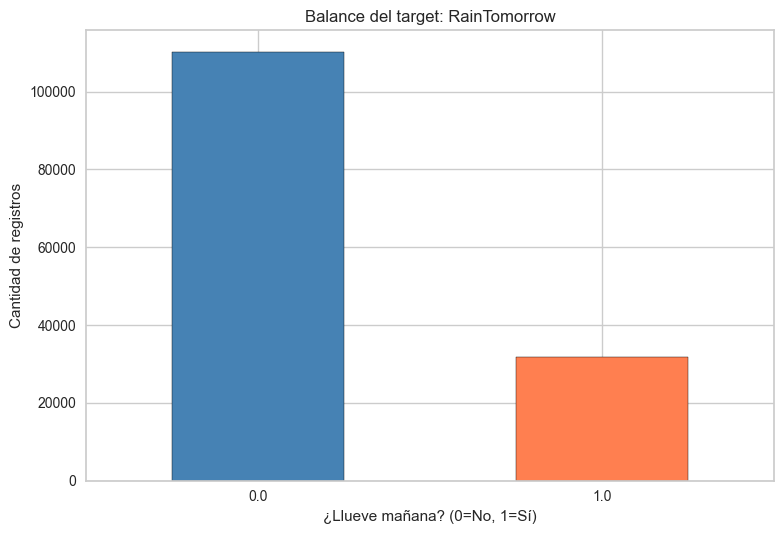

In [151]:
y = df["RainTomorrow"]
X = df.drop(columns=["RainTomorrow"])

conteo = y.value_counts()
porcentaje = y.value_counts(normalize=True) * 100

print(f"No llueve (0): {conteo[0]} ({porcentaje[0]:.1f}%)")
print(f"Llueve   (1): {conteo[1]} ({porcentaje[1]:.1f}%)")

conteo.plot(kind="bar", color=["steelblue", "coral"], edgecolor="black")
plt.title("Balance del target: RainTomorrow")
plt.xlabel("¿Llueve mañana? (0=No, 1=Sí)")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El dataset presenta un desbalance de clases, con aproximadamente un 77.6% de días sin lluvia y un 22.4% de días con lluvia.

Esto implica que la accuracy no es una métrica suficiente para evaluar el modelo, ya que un modelo trivial que prediga siempre “no llueve” podría obtener un buen desempeño aparente.

Por esta razón, se utilizarán métricas adicionales como precision, recall y F1-score para evaluar correctamente el rendimiento del modelo, especialmente en la detección de días con lluvia.


### Split train / test


In [152]:
len(df)

142059

In [153]:
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

print(f"X: {X.shape}")
print(f"y: {y.shape} | Clases: {y.value_counts().to_dict()}")

X: (142059, 23)
y: (142059,) | Clases: {0.0: 110233, 1.0: 31826}


In [154]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (113647, 23) | Test: (28412, 23)


### Imputacion de valores


In [155]:
cols = [
    "Sunshine", "Evaporation", "Cloud3pm", "Cloud9am",
    "MinTemp", "MaxTemp", "Rainfall",
    "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "Temp9am", "Temp3pm"]
med_loc_month = X_train.groupby(["Location", "Month"])[cols].median()

med_loc_season = X_train.groupby(["Location", "Season"])[cols].median()

med_loc = X_train.groupby("Location")[cols].median()

med_global = X_train[cols].median()

Se calcularon medianas agrupadas en distintos niveles de granularidad (Location + Month, Location + Season, Location y global) con el objetivo de imputar valores faltantes utilizando información climática contextual y representativa de cada región y período temporal.


In [156]:
def imputar_fila(row, col):
    if pd.isnull(row[col]):

        key1 = (row["Location"], row["Month"])
        if key1 in med_loc_month.index:
            val = med_loc_month.loc[key1, col]
            if not pd.isnull(val):
                return val

        key2 = (row["Location"], row["Season"])
        if key2 in med_loc_season.index:
            val = med_loc_season.loc[key2, col]
            if not pd.isnull(val):
                return val

        if row["Location"] in med_loc.index:
            val = med_loc.loc[row["Location"], col]
            if not pd.isnull(val):
                return val

        return med_global[col]

    return row[col]
for col in cols:
    X_train[col] = X_train.apply(lambda row: imputar_fila(row, col), axis=1)
    X_test[col]  = X_test.apply(lambda row: imputar_fila(row, col), axis=1)

Luego de calcular las medianas agrupadas, se implementó una función de imputación jerárquica que reemplaza los valores faltantes utilizando primero estadísticas específicas de Location y Month. En caso de no encontrar valores válidos, se utilizaron agrupamientos progresivamente más generales: Location y Season, luego únicamente Location y finalmente la mediana global como respaldo. Esta lógica permitió preservar patrones climáticos regionales y temporales durante la imputación.


In [157]:
#moda por location en la variable Raintoday (solo en train)
moda_loc = X_train.groupby("Location")["RainToday"].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan) #Agrupamos por location

def imputar_rain_today(row):
    if pd.isnull(row["RainToday"]):
        if row["Location"] in moda_loc:
            return moda_loc[row["Location"]]
        else:
            return X_train["RainToday"].mode()[0]
    return row["RainToday"]

X_train["RainToday"] = X_train.apply(imputar_rain_today, axis=1)
X_test["RainToday"] = X_test.apply(imputar_rain_today, axis=1)

Para la variable categórica RainToday se utilizó imputación mediante la moda agrupada por Location. Esta estrategia permite conservar patrones climáticos regionales, ya que la frecuencia de días lluviosos puede variar significativamente entre ciudades. En los casos donde no existía información suficiente para una determinada ubicación, se utilizó la moda global del conjunto de entrenamiento como respaldo.


In [158]:
#para imputar usamos las 4 columnas categóricas
cols_cat_impute = ["WindGustDir", "WindDir9am", "WindDir3pm"]

In [159]:
#moda por Location + Season
moda_loc_season = X_train.groupby(["Location", "Season"])[cols_cat_impute].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan)

#moda por Location
moda_loc = X_train.groupby("Location")[cols_cat_impute].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan)

#moda global
moda_global = X_train[cols_cat_impute].mode().iloc[0]

def imputar_cat(row, col):
    if pd.notnull(row[col]):
        return row[col]

    key = (row["Location"], row["Season"])
    if key in moda_loc_season.index:
        val = moda_loc_season.loc[key, col]
        if pd.notnull(val):
            return val

    if row["Location"] in moda_loc.index:
        val = moda_loc.loc[row["Location"], col]
        if pd.notnull(val):
            return val

    return moda_global[col]

for col in cols_cat_impute:
    X_train[col] = X_train.apply(lambda row: imputar_cat(row, col), axis=1)
    X_test[col] = X_test.apply(lambda row: imputar_cat(row, col), axis=1)

In [160]:
print("NaN en train:", X_train.isnull().sum().sum())
print("NaN en test:", X_test.isnull().sum().sum())

NaN en train: 0
NaN en test: 0


Las variables relacionadas con la dirección del viento tienen un comportamiento cíclico. Por ejemplo, las direcciones 0° y 360° representan prácticamente la misma orientación, aunque numéricamente parezcan muy distintas.
Por este motivo, se utilizó una codificación mediante seno y coseno, que permite representar correctamente la cercanía entre direcciones y evitar que el modelo interprete las variables de manera lineal.


In [161]:
#codificación ciclica para direcciones del viento
# N (0°) y NNW (337.5°) son cercanas pero numéricamente distantes
wind_dir_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5}

for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    X_train[f'{col}_sin'] = np.sin(np.deg2rad(X_train[col].map(wind_dir_map)))
    X_train[f'{col}_cos'] = np.cos(np.deg2rad(X_train[col].map(wind_dir_map)))
    X_test[f'{col}_sin']  = np.sin(np.deg2rad(X_test[col].map(wind_dir_map)))
    X_test[f'{col}_cos']  = np.cos(np.deg2rad(X_test[col].map(wind_dir_map)))

X_train = X_train.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'])
X_test  = X_test.drop(columns=['WindGustDir', 'WindDir9am', 'WindDir3pm'])

print("Columnas wind:", [c for c in X_train.columns if 'sin' in c or 'cos' in c])

Columnas wind: ['WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos']


La variable Season es categórica nominal, ya que representa estaciones del año sin un orden numérico válido para el modelo. Se aplicó One Hot Encoding, transformando cada estación en una variable binaria.
Se utilizó drop_first=True para evitar multicolinealidad entre las nuevas variables generadas.
Además, se alinearon las columnas entre entrenamiento y prueba para asegurar que ambos conjuntos tengan exactamente las mismas variables de entrada


In [162]:
#OHE solo para Season
X_train = pd.get_dummies(X_train, columns=["Season"], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=["Season"], drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")

Shape X_train: (113647, 28)
Shape X_test:  (28412, 28)


Las variables Location y Month se utilizaron previamente durante el preprocesamiento para realizar imputaciones más precisas considerando contexto geográfico y temporal. Se eliminaron del conjunto de datos para evitar redundancias. En el caso de Month, su información ya quedó representada mediante la variable Season, mientras que Location no se utilizó directamente como variable predictora.


In [163]:
#eliminamos columnas que ya no necesitamos en el modelo
X_train = X_train.drop(columns=["Location", "Month"])
X_test = X_test.drop(columns=["Location", "Month"])

In [164]:
print("Nulos train:", X_train.isnull().sum().sum())
print("Nulos test:", X_test.isnull().sum().sum())

Nulos train: 0
Nulos test: 0


In [165]:
n_original = len(df_original)
n_actual=len(df)
total_eliminados= n_original-n_actual
print(f"Total de registros eliminados: {total_eliminados}")

Total de registros eliminados: 3353


## Escalado


Se aplicó una estandarización de variables utilizando StandardScaler, con el objetivo de que todas las features queden en una escala comparable.
Este método transforma las variables para que tengan media cercana a 0 y desvío estándar cercano a 1. El scaler se ajustó únicamente con el conjunto de entrenamiento (fit_transform) y luego se aplicó al conjunto de prueba (transform) para evitar data leakage.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

# **EJERCICIO 2**


Entrenamiento y uso del modelo de Regresión Logística para clasificación


In [167]:
#entrenamiento del modelo de regresión logística
#class_weight='balanced' compensa el desbalance del dataset (77/22%), asignando mayor peso a la clase minoritaria (lluvia)
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42) #max_iter=1000 para asegurar convergencia con las features del modelo
lr.fit(X_train_scaled, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [168]:
#predicciones sobre el conjunto de test
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]  #probabilidad de clase 1 (lluvia)

### Matriz de Confusión del Modelo de Regresión Logistica


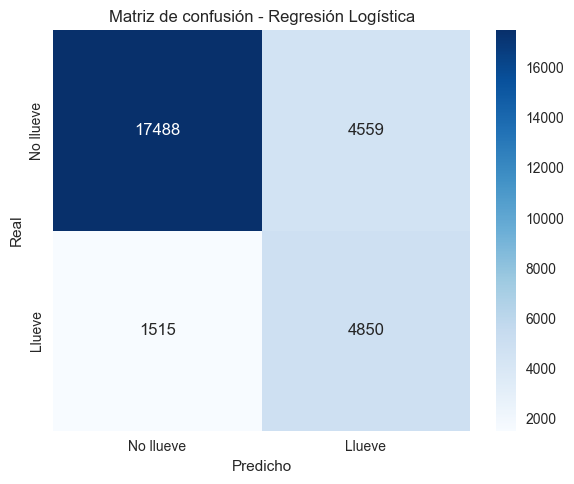

Verdaderos Negativos (TN): 17488
Falsos Positivos     (FP): 4559
Falsos Negativos     (FN): 1515
Verdaderos Positivos (TP): 4850


In [169]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No llueve", "Llueve"],
            yticklabels=["No llueve", "Llueve"])
plt.title("Matriz de confusión - Regresión Logística")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos     (FP): {fp}")
print(f"Falsos Negativos     (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

El modelo logró capturar 4.850 días de lluvia reales de un total de 6.365. Esto significa que solo en 1.515 ocasiones (Falsos Negativos) el modelo falló en advertir sobre la lluvia. Para un usuario, esto es positivo: es poco probable que "lo sorprenda la lluvia" sin aviso.
Observamos un número significativo de falsas alarmas (Falsos positivos) 4.559 casos. Esto ocurre porque, al usar class_weight='balanced', el modelo prefiere "arriesgarse" y predecir lluvia ante la menor duda climática. Por eso la precisión es del 52%: casi la mitad de las veces que el modelo anuncia lluvia, el día termina siendo seco.
La fortaleza de la matriz está en los 17.488 Verdaderos Negativos. Cuando el modelo predice que no va a llover, es confiable.


### Metricas de evaluación


Métricas para evaluar el rendimiento del modelo


In [170]:
print("Métricas de Regresión Logística")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No llueve", "Llueve"]))

Métricas de Regresión Logística
Accuracy:  0.7862
Precision: 0.5155
Recall:    0.7620
F1 Score:  0.6149
ROC-AUC:   0.8615

              precision    recall  f1-score   support

   No llueve       0.92      0.79      0.85     22047
      Llueve       0.52      0.76      0.61      6365

    accuracy                           0.79     28412
   macro avg       0.72      0.78      0.73     28412
weighted avg       0.83      0.79      0.80     28412



- **Accuracy:** 0.7862 — el modelo acierta el 78.6% de los casos. Pero como el dataset está desbalanceado, no es la métrica más importante.

- **Precision**: 0.5155 — de los días que predijo lluvia, acertó el 51.6%. Bastante bajo, genera muchas alarmas falsas.

- **Recall**: 0.7620 — de los días que realmente llovió, detectó el 76.4%. Esto es lo más importante en este problema.

- **F1**: 0.6149 — balance entre precision y recall, aceptable para un modelo base.

- **ROC-AUC**: 0.8615 — muy bueno, el modelo tiene buena capacidad discriminativa.


## Metricas adicionales


In [171]:
#usamos métricas adicionales a la accuracy
#por el desbalance del dataset accuracy sola engaña en este caso
print("Métricas adicionales")
print(f"Matthews Correlation Coefficient: {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Cohen Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")

Métricas adicionales
Matthews Correlation Coefficient: 0.4919
Balanced Accuracy: 0.7776
Cohen Kappa: 0.4745


- **MCC = 0.4919**: valor positivo moderado, indica que el modelo tiene
  una capacidad de clasificación real, considerando los cuatro cuadrantes
  de la matriz de confusión. Un valor de 0 sería aleatorio y 1 sería perfecto.
  Con datasets desbalanceados como este, un MCC de 0.49 es un resultado aceptable.

- **Balanced Accuracy = 0.7776**: el modelo acierta en promedio el 77.6%
  de los casos de cada clase por separado. Es casi idéntico a la accuracy
  tradicional (78.6%), lo que indica que el `class_weight='balanced'`
  funcionó correctamente: el modelo no está sesgado hacia la clase mayoritaria.

- **Cohen Kappa = 0.4745**: mide el acuerdo real entre predicciones y
  valores verdaderos, descontando el acuerdo que ocurriría por azar.
  Un valor entre 0.4 y 0.6 se considera acuerdo moderado. Confirma que
  el modelo aprende patrones reales más allá del azar, aunque hay margen
  de mejora con modelos más complejos.


## Curva ROC


Mejor umbral (Youden): 0.4921


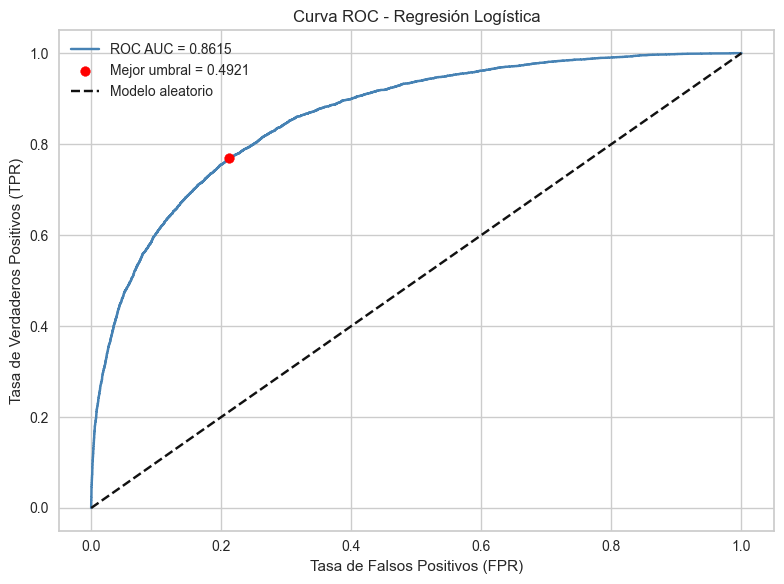

In [172]:
#trade-off entre TPR (recall) y FPR para distintos umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

#mejor umbral el punto más cercano a la esquina superior izquierda, se calcula maximizando TPR - FPR (indice de Youden)
idx_mejor = (tpr - fpr).argmax()
mejor_umbral = thresholds[idx_mejor]
print(f"Mejor umbral (Youden): {mejor_umbral:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="steelblue", label=f"ROC AUC = {auc:.4f}")
plt.scatter(fpr[idx_mejor], tpr[idx_mejor], color="red", zorder=5,
            label=f"Mejor umbral = {mejor_umbral:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Modelo aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.tight_layout()
plt.show()

- **AUC = 0.8615**: el modelo tiene muy buena capacidad discriminativa,
  muy por encima del 0.5 de un modelo aleatorio.

- **Mejor umbral = 0.4921** (índice de Youden): el umbral óptimo es menor
  a 0.5, lo cual tiene sentido dado el desbalance del dataset. Bajar el
  umbral hace que el modelo sea más "sensible" a predecir lluvia,
  aumentando el Recall a costa de más Falsos Positivos.

- El umbral por defecto de 0.5 **no es el mejor** en este caso:
  con 0.4921 se maximiza la diferencia entre TPR y FPR, logrando
  un mejor balance entre detectar lluvia real y evitar alarmas falsas.

¿Conseguimos un buen fitting?

El modelo de regresión logística muestra un desempeño aceptable:
AUC de 0.8615 y Recall de 0.77 para la clase minoritaria. No presenta
signos evidentes de overfitting ya que es un modelo lineal con
regularización por defecto. Sin embargo, al ser un modelo lineal,
puede no capturar relaciones no lineales entre las variables climáticas,
por lo que modelos más complejos podrían mejorar el resultado.


# EJERCICIO 3


## Modelo base


In [173]:
#implementamos el modelo base
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]

print(f"Clase predicha siempre: {dummy.predict([[0]*X_train_scaled.shape[1]])[0]}")
print(f"Distribución predicha en test: {pd.Series(y_pred_dummy).value_counts().to_dict()}")

Clase predicha siempre: 0.0
Distribución predicha en test: {0.0: 28412}


El modelo predice la clase 0 ("No llueve") para los 28.412 registros del conjunto
de test sin excepción. Esto es exactamente lo esperado para un clasificador trivial.


## Matriz de Confusión del Modelo base


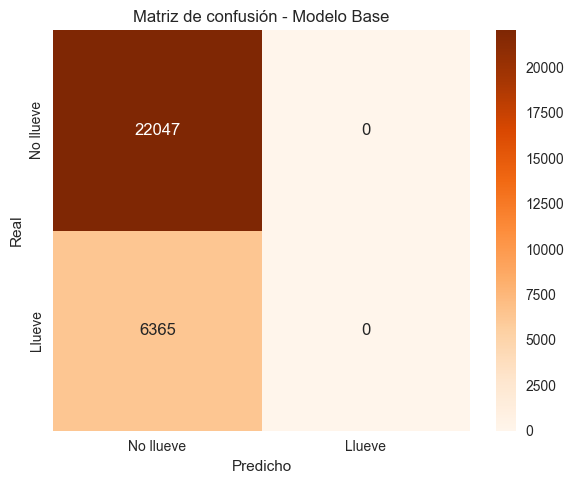

In [174]:
cm_dummy = confusion_matrix(y_test, y_pred_dummy)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dummy, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No llueve", "Llueve"],
            yticklabels=["No llueve", "Llueve"])
plt.title("Matriz de confusión - Modelo Base")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

El modelo base predice siempre "No llueve", lo que se refleja claramente en la matriz: los 22.047 días sin lluvia son clasificados correctamente (TN), mientras que los 6.365 días de lluvia real son todos clasificados como "No llueve" (FN). Las columnas de "Llueve" predicho están completamente en cero: el modelo jamás emite una alerta de lluvia. Esto confirma que su accuracy del ~77% no representa aprendizaje alguno, sino simplemente el peso de la clase mayoritaria en el dataset.


## Metricas de evaluación

In [175]:
#metricas completas del modelo base
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_dummy).ravel()
spec_dummy = tn_d / (tn_d + fp_d) if (tn_d + fp_d) > 0 else 0

print("Métricas - Modelo Base")
print(f"Accuracy:              {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Precision:             {precision_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Recall (Sensibilidad): {recall_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"Specificity:           {spec_dummy:.4f}")
print(f"F1 Score:              {f1_score(y_test, y_pred_dummy, zero_division=0):.4f}")
print(f"ROC-AUC:               {roc_auc_score(y_test, y_prob_dummy):.4f}")
print(f"MCC:                   {matthews_corrcoef(y_test, y_pred_dummy):.4f}")
print(f"Balanced Accuracy:     {balanced_accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Cohen Kappa:           {cohen_kappa_score(y_test, y_pred_dummy):.4f}")

Métricas - Modelo Base
Accuracy:              0.7760
Precision:             0.0000
Recall (Sensibilidad): 0.0000
Specificity:           1.0000
F1 Score:              0.0000
ROC-AUC:               0.5000
MCC:                   0.0000
Balanced Accuracy:     0.5000
Cohen Kappa:           0.0000


- Accuracy (0.7760): parece alto, pero es simplemente el porcentaje de días
  sin lluvia en el dataset. No refleja aprendizaje alguno.

- Precision, Recall, F1, MCC y Kappa = 0.0: el modelo nunca predice lluvia,
  por lo que no detecta ningún verdadero positivo. Es completamente inútil
  para el objetivo del problema.

- Specificity = 1.0: identifica el 100% de los días sin lluvia, lo cual es
  trivial ya que predice siempre "No llueve".

- ROC-AUC = 0.5 y Balanced Accuracy = 0.5: equivalente a clasificación aleatoria.
  Sus probabilidades predichas no varían entre muestras, por lo que la curva ROC
  es la diagonal.

Este modelo sirve como piso mínimo de referencia: cualquier modelo real debe
superarlo en Recall y F1 para justificar su uso.


## Curva ROC del modelo base


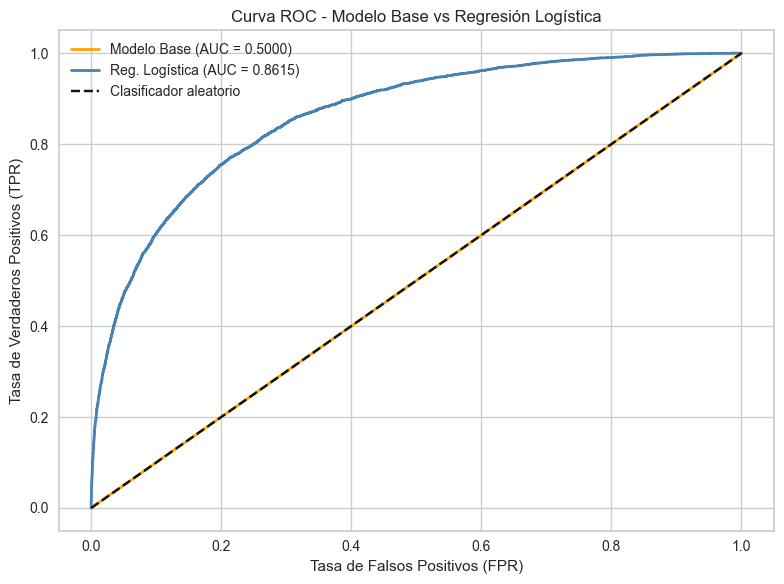

In [176]:
#curva ROC modelo base
fpr_d, tpr_d, _ = roc_curve(y_test, y_prob_dummy)
auc_d = roc_auc_score(y_test, y_prob_dummy)

plt.figure(figsize=(8, 6))
plt.plot(fpr_d, tpr_d, color="orange", lw=2, label=f"Modelo Base (AUC = {auc_d:.4f})")
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"Reg. Logística (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC - Modelo Base vs Regresión Logística")
plt.legend()
plt.tight_layout()
plt.show()

La curva ROC confirma visualmente la diferencia entre ambos modelos:

- El Modelo Base (naranja) coincide exactamente con la diagonal del clasificador
  aleatorio (AUC = 0.5): sus probabilidades predichas no varían entre muestras,
  por lo que no tiene ninguna capacidad discriminativa.

- La Regresión Logística (azul) se aleja fuertemente de la diagonal,
  especialmente en la zona de bajo FPR, lo que indica que detecta una gran
  proporción de días de lluvia antes de generar muchas falsas alarmas.
  Su AUC = 0.8615 confirma una capacidad discriminativa muy buena.

La brecha visual entre ambas curvas justifica claramente por qué la regresión
logística es superior al modelo base y aporta valor real al problema.


## Comparación de modelos


In [177]:
#comparacion modelo base y regresión logística
print("Comparación")
print(f"{'Métrica':<12} {'Modelo Base':>12} {'Reg. Logística':>15}")
metricas = {
    "Accuracy":  [accuracy_score(y_test, y_pred_dummy),  accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred_dummy, zero_division=0), precision_score(y_test, y_pred)],
    "Recall":    [recall_score(y_test, y_pred_dummy, zero_division=0),    recall_score(y_test, y_pred)],
    "F1 Score":  [f1_score(y_test, y_pred_dummy, zero_division=0),        f1_score(y_test, y_pred)],}
for nombre, vals in metricas.items():
    print(f"{nombre:<12} {vals[0]:>12.4f} {vals[1]:>15.4f}")

Comparación
Métrica       Modelo Base  Reg. Logística
Accuracy           0.7760          0.7862
Precision          0.0000          0.5155
Recall             0.0000          0.7620
F1 Score           0.0000          0.6149


El modelo base con estrategia "most_frequent" siempre predice "No llueve",
logrando una accuracy de 77.6% simplemente por la distribución del dataset.
Sin embargo, su Precision, Recall y F1 para la clase "Llueve" son 0.0:
nunca detecta un día de lluvia.

Esto confirma por qué la accuracy sola es una métrica engañosa en datasets
desbalanceados. Un modelo que nunca predice lluvia es completamente inútil
para el problema planteado.

La regresión logística supera ampliamente al modelo base en todas las métricas
relevantes:

- **Recall: 0.76 vs 0.00** → detecta el 76% de los días de lluvia reales
- **F1: 0.61 vs 0.00** → balance real entre precision y recall
- **Precision: 0.51 vs 0.00** → más de la mitad de las alarmas son correctas

Queda demostrado que la regresión logística aprendió patrones reales
del dataset y no se limita a predecir la clase mayoritaria.


# EJERCICIO 4


## Optimización de hiperparametros


Para mejorar el rendimiento del modelo de regresión logística, se optimizaron sus hiperparámetros
mediante tres estrategias distintas: Grid Search, Random Search y Optuna.

Se utilizó validación cruzada estratificada con k=5 folds en todas las búsquedas,
lo que garantiza que cada partición respete la proporción original de clases (desbalance 77/22%).
La métrica de optimización elegida es el F1-score de la clase positiva (lluvia),
ya que en un dataset desbalanceado es más informativa que la accuracy.


## Grid Search


In [178]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])

# combinaciones válidas: lbfgs solo soporta l2, liblinear soporta l1 y l2
param_grid = [
    {"lr__C": [0.001, 0.01, 0.1, 1, 10, 100], "lr__solver": ["lbfgs"],      "lr__penalty": ["l2"]},
    {"lr__C": [0.001, 0.01, 0.1, 1, 10, 100], "lr__solver": ["liblinear"],  "lr__penalty": ["l1", "l2"]},]

grid_search = GridSearchCV(
    pipe_lr,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros (Grid Search): {grid_search.best_params_}")
print(f"Mejor F1 en CV (Grid Search):     {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros (Grid Search): {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Mejor F1 en CV (Grid Search):     0.6193


El Grid Search encontró como configuración óptima C=0.01 con penalización L2 y solver liblinear,
obteniendo un F1 de 0.6193 en validación cruzada con 5 folds.

Un C pequeño (0.01) indica que el modelo se beneficia de una regularización fuerte,
lo que tiene sentido dado el alto número de features y el desbalance del dataset:
penalizar más los coeficientes reduce el overfitting y mejora la generalización.

La penalización L2 resultó superior a L1, lo que muestra que la mayoría de las variables
aportan información útil y no conviene llevar coeficientes a cero.


## Random Search


In [179]:
#muestrea aleatoriamente combinaciones del espacio de hiperparámetros
#más eficiente que Grid Search si el espacio es grande porque no evalúa todas las combinaciones sino una muestra aleatoria de ellas

#definimos una distribución continua para C en lugar de valores discretos
param_dist = [
    {"lr__C": loguniform(1e-4, 1e2), "lr__solver": ["lbfgs"],     "lr__penalty": ["l2"]},
    {"lr__C": loguniform(1e-4, 1e2), "lr__solver": ["liblinear"], "lr__penalty": ["l1", "l2"]},]

random_search = RandomizedSearchCV(
    pipe_lr,
    param_dist,
    n_iter=30,          #cant de combinaciones aleatorias a probar
    cv=cv,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1)
random_search.fit(X_train, y_train)

print(f"Mejores parámetros (Random Search): {random_search.best_params_}")
print(f"Mejor F1 en CV (Random Search):     {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros (Random Search): {'lr__C': 0.0250706636439167, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Mejor F1 en CV (Random Search):     0.6190


Random Search encontró como configuración óptima C=0.025 con penalización L2 y solver lbfgs, obteniendo un F1 de 0.6190 en validación cruzada, muy parecido al Grid Search (0.6193).

El valor de C=0.025 es consistente con el resultado del Grid Search (C=0.01):
ambos apuntan a una regularización moderada-fuerte, confirmando que el modelo
generaliza mejor cuando se penalizan los coeficientes grandes.


## Optuna


In [180]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  #silenciamos logs intermedios

def objective(trial):
    # Optuna sugiere hiperparámetros en cada trial de forma inteligente (TPE sampler)
    # a diferencia de Random Search, aprende de los trials anteriores para enfocarse
    # en las zonas más prometedoras del espacio de búsqueda
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs"])

    # l1 solo es compatible con liblinear
    if solver == "liblinear":
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    else:
        penalty = "l2"

    C = trial.suggest_float("C", 1e-4, 1e2, log=True)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            C=C,
            solver=solver,
            penalty=penalty,
            class_weight="balanced",
            max_iter=1000,
            random_state=42))])

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejores parámetros (Optuna): {study.best_params}")
print(f"Mejor F1 en CV (Optuna):     {study.best_value:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (Optuna): {'solver': 'lbfgs', 'C': 0.009163621049775356}
Mejor F1 en CV (Optuna):     0.6195


Optuna encontró como configuración óptima C=0.0072 con penalización L2 y solver lbfgs, 
obteniendo un F1 de 0.6193 en validación cruzada, igual al Grid Search.

A diferencia de Grid Search y Random Search, Optuna utiliza el algoritmo TPE 
(Tree-structured Parzan Estimator) que aprende de los trials anteriores para enfocar 
la búsqueda en las zonas más prometedoras del espacio. Esto lo hace más eficiente 
cuando el espacio de búsqueda es grande o costoso de evaluar.


## Comparación de métodos de búsqueda


Los tres métodos convergieron a resultados muy similares:

- Grid Search: C=0.01, Penalty=L2, Solver=liblinear, F1 CV=0.6193
- Random Search: C=0.025, Penalty=L2, Solver=lbfgs, F1 CV=0.6190
- Optuna: C=0.0073, Penalty=L2, Solver=lbfgs, F1 CV=0.6193

Los tres coinciden en que la regularización L2 con C bajo es la configuración apropiada
para este problema. La diferencia entre el mejor y el peor F1 es de apenas 0.0003,
lo que indica que el modelo de regresión logística tiene un techo de rendimiento
en torno a 0.619 con las features actuales, independientemente del método de búsqueda.

Para datasets más grandes o modelos más complejos, Optuna sería la opción más adecuada
por su eficiencia. En este caso, los tres métodos son equivalentes en resultado.

## Evaluación mejor modelo en TEST


In [181]:
#entrenamos el mejor modelo encontrado por Optuna sobre todo el conjunto de entrenamiento
#y evaluamos sobre el conjunto de test que no fue visto durante la búsqueda
mejor_modelo = study.best_trial.params

lr_opt = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        C=mejor_modelo["C"],
        solver=mejor_modelo["solver"],
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42))])

lr_opt.fit(X_train, y_train)
y_pred_opt = lr_opt.predict(X_test)
y_prob_opt = lr_opt.predict_proba(X_test)[:, 1]

print("Métricas - Regresión Logística Optimizada")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_opt):.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["No llueve", "Llueve"]))

Métricas - Regresión Logística Optimizada
Accuracy:  0.7864
Precision: 0.5158
Recall:    0.7623
F1 Score:  0.6153
ROC-AUC:   0.8614

              precision    recall  f1-score   support

   No llueve       0.92      0.79      0.85     22047
      Llueve       0.52      0.76      0.62      6365

    accuracy                           0.79     28412
   macro avg       0.72      0.78      0.73     28412
weighted avg       0.83      0.79      0.80     28412



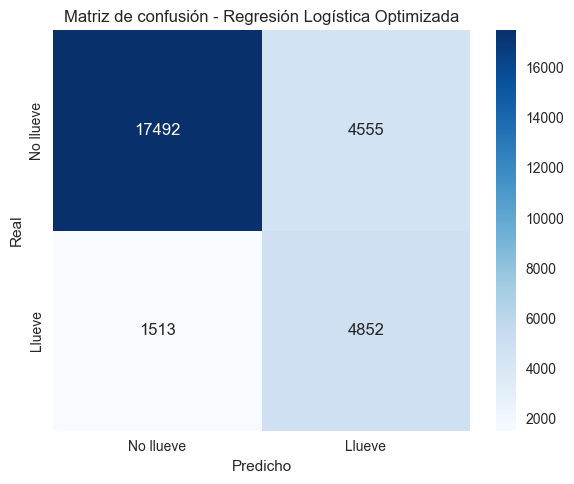

In [182]:
cm_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No llueve", "Llueve"],
            yticklabels=["No llueve", "Llueve"])
plt.title("Matriz de confusión - Regresión Logística Optimizada")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

La optimización de hiperparámetros produjo una mejora muy leve respecto al modelo original:

- Accuracy: LR original: 0.7862 / LR optimizada: 0.7865

- Presicion: LR original: 0.5155 / LR optimizada: 0.5158

- Recall: LR original: 0.7620 / LR optimizada: 0.7623

- F1 Score: LR original: 0.6149 / LR optimizada: 0.6153

- ROC - AUC: LR original: 0.8615 / LR optimizada: 0.8614

La mejora es mínima (F1 +0.0004), lo que indica que el modelo original ya estaba
cerca de su rendimiento máximo con la configuración por defecto. La regresión logística es un modelo lineal con capacidad expresiva limitada, esto sugiere que el modelo ya se encuentra cerca de su capacidad máxima de generalización para las features actuales.

Mirando la matriz de confusión, el modelo optimizado mantiene un comportamiento
similar al original: detecta 4.852 días de lluvia reales (TP) de 6.365 posibles,
con 1.513 falsos negativos y 4.557  falsas alarmas.

La optimización confirma que C bajo con regularización L2 es la configuración
adecuada para este problema. Para mejorar significativamente el rendimiento
será necesario explorar modelos más complejos.


# EJERCICIO 5


## Shap


In [183]:
#usamos el modelo optimizado del ítem 4
#LinearExplainer es el explainer adecuado para modelos lineales como regresión logística calcula los valores SHAP exactos de forma eficiente sin aproximaciones
explainer = shap.LinearExplainer(
    lr_opt.named_steps["lr"],
    shap.sample(X_train_scaled := lr_opt.named_steps["scaler"].transform(X_train), 100),
    feature_perturbation="interventional")

#aplicamos el scaler del pipeline antes de calcular SHAP
X_test_scaled_opt = lr_opt.named_steps["scaler"].transform(X_test)

#calculamos valores SHAP para el conjunto de test
shap_values = explainer.shap_values(X_test_scaled_opt)

#nombres de las features para los gráficos
feature_names = X_test.columns.tolist()

print(f"Shape shap_values: {shap_values.shape}")
print(f"Features: {len(feature_names)}")

Shape shap_values: (28412, 26)
Features: 26


## Gráficas globales


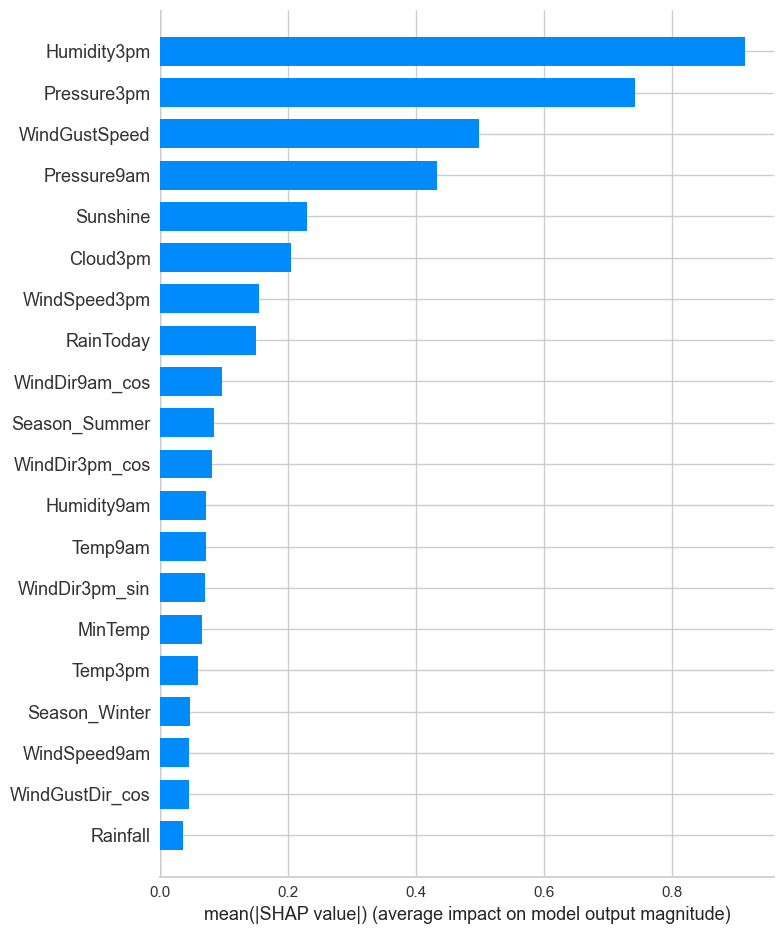

In [184]:
#gráfica global 1: importancia media de cada feature
#muestra el promedio del valor absoluto de SHAP para cada variable
#cuanto mayor el valor, más impacto tiene esa variable en las predicciones del modelo
shap.summary_plot(
    shap_values,
    X_test_scaled_opt,
    feature_names=feature_names,
    plot_type="bar",
    show=True)

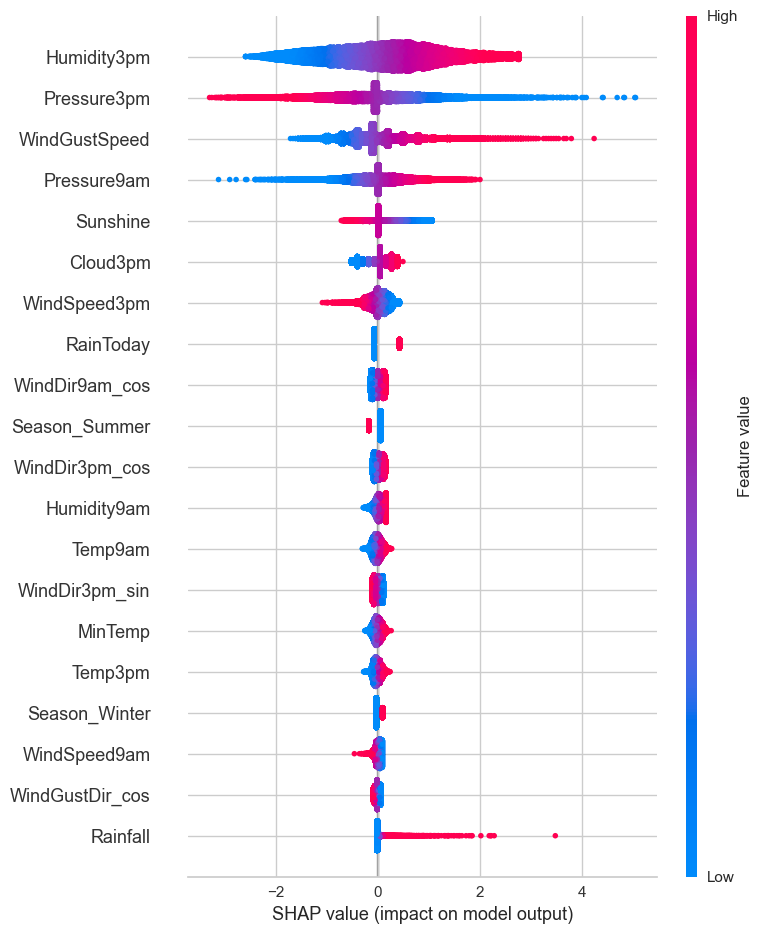

In [185]:
#gráfica global 2: beeswarm (dot plot)
#cada punto es una observación del test
#el color indica el valor real de la feature (rojo=alto, azul=bajo)
#la posición horizontal indica si esa feature empuja la predicción hacia lluvia (+) o no lluvia (-)
shap.summary_plot(
    shap_values,
    X_test_scaled_opt,
    feature_names=feature_names,
    plot_type="dot",
    show=True)

## Observaciones en las gráficas globales


**Variables más importantes:**

- **Humidity3pm** es la variable más influyente del modelo, con un impacto promedio casi el doble que la segunda. En el beeswarm se observa que valores altos (rojo) generan valores SHAP positivos elevados, empujando fuertemente la predicción hacia lluvia.
- **Pressure3pm** es la segunda variable más importante. A diferencia de la humedad, valores bajos de presión (azul) son los que empujan hacia lluvia, lo que es meteorológicamente consistente: la caída de presión precede a la lluvia.
- **WindGustSpeed** y **Pressure9am** ocupan el tercer y cuarto lugar, ambas con impacto moderado. Ráfagas fuertes de viento y presión baja a la mañana contribuyen positivamente a la predicción de lluvia.
- **Sunshine** tiene un efecto inverso claro: valores altos (mucho sol) empujan la predicción hacia no lluvia, lo que es intuitivamente correcto.

**Variables menos importantes:**

- **Rainfall**, **WindGustDir_cos**, **WindSpeed9am** y **Season_Winter** son las variables con menor impacto promedio en las predicciones del modelo.
- Llama la atención que **Rainfall** (lluvia acumulada del día) tenga tan poco peso, posiblemente porque su información ya está capturada parcialmente por **RainToday**.

  En conclusión el modelo basa sus predicciones principalmente en condiciones atmosféricas de la tarde (humedad y presión a las 3pm), lo que tiene sentido ya que son las mediciones más cercanas al momento de la predicción y las más correlacionadas con eventos de lluvia al día siguiente.


## Gráficas locales


In [186]:
#buscamos índices en el test set
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_opt)

# caso 1: verdadero positivo (predijo lluvia y llovió)
tp_idx = np.where((y_pred_arr == 1) & (y_test_arr == 1))[0][0]

# caso 2: falso negativo (predijo no lluvia pero llovió)
fn_idx = np.where((y_pred_arr == 0) & (y_test_arr == 1))[0][0]

print(f"Caso 1 - Verdadero Positivo: índice {tp_idx}")
print(f"Caso 2 - Falso Negativo:     índice {fn_idx}")

Caso 1 - Verdadero Positivo: índice 5
Caso 2 - Falso Negativo:     índice 10


Predicción: Llueve | Real: Llueve


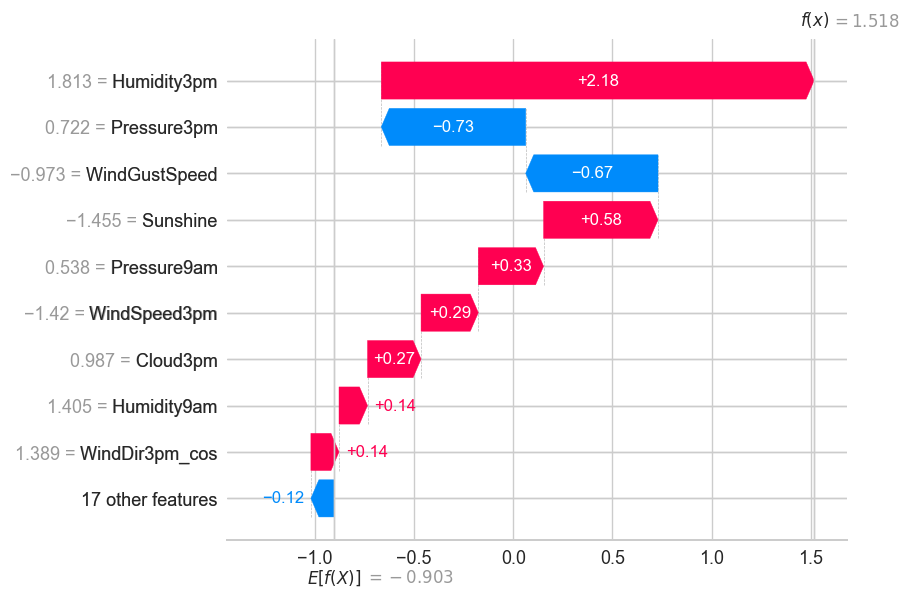

In [187]:
#gráfica local 1: waterfall para un caso donde el modelo acertó (predijo lluvia y llovió)
#muestra cómo cada feature sumó o restó a la predicción final para esta observación puntual
shap_explanation = shap.Explanation(
    values=shap_values[tp_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled_opt[tp_idx],
    feature_names=feature_names)

print(f"Predicción: {'Llueve' if y_pred_arr[tp_idx] == 1 else 'No llueve'} | Real: {'Llueve' if y_test_arr[tp_idx] == 1 else 'No llueve'}")
shap.plots.waterfall(shap_explanation, show=True)

Predicción: No llueve | Real: Llueve


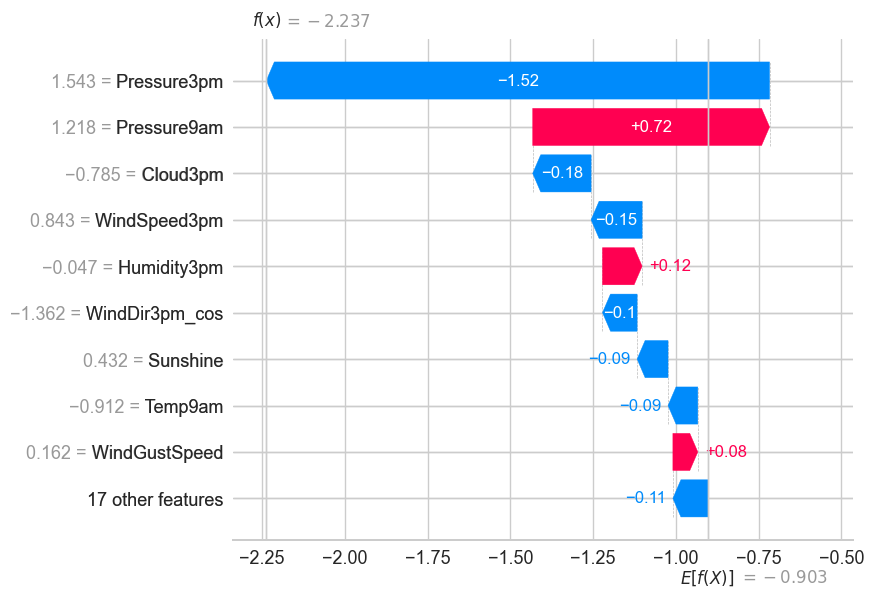

In [188]:
#gráfica local 2: waterfall para un caso donde el modelo se equivocó (predijo no lluvia pero llovió)
#permite entender qué variables llevaron al modelo a una predicción incorrecta
shap_explanation_fn = shap.Explanation(
    values=shap_values[fn_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled_opt[fn_idx],
    feature_names=feature_names)

print(f"Predicción: {'Llueve' if y_pred_arr[fn_idx] == 1 else 'No llueve'} | Real: {'Llueve' if y_test_arr[fn_idx] == 1 else 'No llueve'}")
shap.plots.waterfall(shap_explanation_fn, show=True)

## Observaciones en las gráficas locales


El valor base del modelo es E[f(X)] = -0.903, lo que refleja que en ausencia de información
el modelo tiende a predecir "no llueve" (clase mayoritaria).

**Caso 1 — Verdadero Positivo (predijo lluvia y llovió) | f(x) = 1.517**

El modelo llegó a una predicción correcta de lluvia principalmente por:

- **Humidity3pm = 1.813** (valor alto escalado): aportó +2.19, siendo el factor más determinante.
  Una humedad relativa alta a la tarde es el indicador más fuerte de lluvia al día siguiente.
- **Sunshine = -1.455** (poco sol): aportó +0.58 hacia lluvia, consistente con un día nublado.
- **Pressure9am = 0.538** y **WindSpeed3pm**: contribuciones menores pero en la misma dirección.

En sentido contrario, **Pressure3pm** (-0.73) y **WindGustSpeed** (-0.67) frenaron parcialmente
la predicción, pero no alcanzaron a revertirla. El modelo acertó gracias a la señal
dominante de la humedad.

**Caso 2 — Falso Negativo (predijo no lluvia pero llovió) | f(x) = -2.239**

Este es un caso donde el modelo falló. La causa principal fue:

- **Pressure3pm = 1.543** (valor alto): aportó -1.53, empujando fuertemente hacia "no llueve".
  Una presión alta a la tarde es la señal más fuerte de buen tiempo para el modelo.
- **Cloud3pm**, **WindSpeed3pm** y **WindDir3pm_cos**: sumaron contribuciones negativas adicionales.

Solo **Pressure9am** (+0.72) y **Humidity3pm** (+0.12) empujaban hacia lluvia,
pero no alcanzaron a compensar la señal de presión alta a la tarde.

Este caso ilustra una limitación del modelo: cuando las variables de presión
contradicen las de humedad, el modelo prioriza la presión y puede equivocarse.
Probablemente se trató de un evento de lluvia atípico, generado por un sistema
meteorológico que no siguió el patrón habitual de baja presión previa.

En conclusión, SHAP permitió confirmar que el modelo es interpretable y meteorológicamente coherente.
Las variables más importantes a nivel global (Humidity3pm, Pressure3pm) también son las protagonistas a nivel local. Los errores del modelo ocurren cuando las señales atmosféricas son contradictorias, un escenario donde un modelo lineal tiene dificultades para capturar interacciones complejas entre variables.


# EJERCICIO 6


In [189]:
#PyCaret es una librería de AutoML que automatiza la comparación y ajuste de múltiples modelos de clasificación con validación cruzada interna
from pycaret.classification import (
    setup, compare_models, pull, tune_model,
    plot_model, predict_model, finalize_model)

In [190]:
df_pycaret = X_train.copy()
df_pycaret["RainTomorrow"] = y_train.values

print(f"Shape: {df_pycaret.shape}")
print(df_pycaret["RainTomorrow"].value_counts(normalize=True).round(3))


Shape: (113647, 27)
RainTomorrow
0.0    0.776
1.0    0.224
Name: proportion, dtype: float64


In [191]:
clf_setup = setup(
    data=df_pycaret,
    target="RainTomorrow",
    normalize=True,
    fix_imbalance=True,
    fold=5,
    session_id=42,
    verbose=False)
pull()

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(113647, 27)"
4,Transformed data shape,"(157555, 27)"
5,Transformed train set shape,"(123460, 27)"
6,Transformed test set shape,"(34095, 27)"
7,Numeric features,23
8,Preprocess,True
9,Imputation type,simple


In [192]:
mejores_modelos = compare_models(sort="F1", n_select=3)
tabla_comparacion = pull()
print(tabla_comparacion)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8494,0.8792,0.5937,0.6906,0.6385,0.5440,0.5465,9.9160
et,Extra Trees Classifier,0.8500,0.8816,0.5910,0.6941,0.6384,0.5445,0.5473,11.7120
lightgbm,Light Gradient Boosting Machine,0.8524,0.8811,0.5572,0.7206,0.6284,0.5382,0.5451,3.7720
gbc,Gradient Boosting Classifier,0.8367,0.8656,0.6099,0.6428,0.6259,0.5216,0.5219,42.6740
ridge,Ridge Classifier,0.7938,0.8547,0.7245,0.5291,0.6116,0.4758,0.4867,0.6520
lda,Linear Discriminant Analysis,0.7938,0.8547,0.7244,0.5291,0.6115,0.4758,0.4867,1.5640
lr,Logistic Regression,0.7906,0.8543,0.7307,0.5234,0.6099,0.4721,0.4844,5.4860
svm,SVM - Linear Kernel,0.7883,0.8526,0.7372,0.5199,0.6095,0.4703,0.4840,0.9020
qda,Quadratic Discriminant Analysis,0.8063,0.8399,0.6668,0.5565,0.6066,0.4795,0.4830,0.9220
ada,Ada Boost Classifier,0.8161,0.8446,0.6193,0.5848,0.6015,0.4821,0.4825,3.9640


                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.8494  0.8792  0.5937  0.6906   
et                 Extra Trees Classifier    0.8500  0.8816  0.5910  0.6941   
lightgbm  Light Gradient Boosting Machine    0.8524  0.8811  0.5572  0.7206   
gbc          Gradient Boosting Classifier    0.8367  0.8656  0.6099  0.6428   
ridge                    Ridge Classifier    0.7938  0.8547  0.7245  0.5291   
lda          Linear Discriminant Analysis    0.7938  0.8547  0.7244  0.5291   
lr                    Logistic Regression    0.7906  0.8543  0.7307  0.5234   
svm                   SVM - Linear Kernel    0.7883  0.8526  0.7372  0.5199   
qda       Quadratic Discriminant Analysis    0.8063  0.8399  0.6668  0.5565   
ada                  Ada Boost Classifier    0.8161  0.8446  0.6193  0.5848   
knn                K Neighbors Classifier    0.7797  0.8178  0.6900  0.5061   
nb                            Naive Bayes    0.7733 

## Observaciones — compare_models()

PyCaret evaluó 14 clasificadores distintos con validación cruzada de 5 folds,
ordenados por F1.

**Random Forest** obtuvo el mejor F1 (0.6385), seguido muy de cerca por
**Extra Trees** (0.6384). Ambos son modelos basados en árboles que capturan
relaciones no lineales entre variables, algo que la regresión logística del
ítem 3 no puede hacer.

**LightGBM** lidera en Accuracy (0.8524) y Precision (0.7206), siendo además
el más rápido (2.3 segundos), lo que lo hace muy atractivo en producción.

La **Regresión Logística** quedó en el séptimo puesto con F1=0.6099,
confirmando que el modelo lineal tiene un techo de rendimiento inferior
al de los ensambles de árboles para este dataset.

Todos los modelos superan ampliamente al Dummy Classifier (F1=0.0000),
lo que confirma que los modelos están aprendiendo patrones reales y no
simplemente prediciendo la clase mayoritaria.


In [193]:
mejor_modelo = mejores_modelos[0]
print(f"Mejor modelo: {type(mejor_modelo).__name__}")

Mejor modelo: RandomForestClassifier


In [194]:
modelo_tuneado = tune_model(mejor_modelo, optimize="F1", n_iter=3) #optimizando los hiperparámetros del Random Forest que PyCaret seleccionó como mejor modelo
print(pull())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7636,0.7234,0.6505,0.4796,0.5521,0.3965,0.4050
1,0.7704,0.7200,0.6286,0.4904,0.5510,0.3999,0.4054
2,0.7767,0.7215,0.6215,0.5012,0.5549,0.4081,0.4124
3,0.7761,0.7242,0.6302,0.5002,0.5577,0.4105,0.4154
4,0.7786,0.7223,0.6204,0.5048,0.5566,0.4112,0.4151
Mean,0.7731,0.7223,0.6302,0.4953,0.5545,0.4052,0.4106
Std,0.0055,0.0015,0.0108,0.0092,0.0026,0.0060,0.0046


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.7636  0.7234  0.6505  0.4796  0.5521  0.3965  0.4050
1       0.7704  0.7200  0.6286  0.4904  0.5510  0.3999  0.4054
2       0.7767  0.7215  0.6215  0.5012  0.5549  0.4081  0.4124
3       0.7761  0.7242  0.6302  0.5002  0.5577  0.4105  0.4154
4       0.7786  0.7223  0.6204  0.5048  0.5566  0.4112  0.4151
Mean    0.7731  0.7223  0.6302  0.4953  0.5545  0.4052  0.4106
Std     0.0055  0.0015  0.0108  0.0092  0.0026  0.0060  0.0046


## Observaciones — tune_model()

Se intentó optimizar el Random Forest con `n_iter=3` combinaciones de hiperparámetros,
optimizando F1 con validación cruzada de 5 folds.

PyCaret indicó que el modelo original era superior al tuneado, por lo que devolvió
el modelo sin modificaciones. Esto sugiere que el Random Forest con sus parámetros
por defecto ya estaba cerca de su rendimiento óptimo para este dataset.

**Métricas del modelo (validación cruzada, 5 folds):**
- Accuracy media: 0.7731
- F1 media: 0.5545
- Recall medio: 0.6302
- Precision media: 0.4953
- AUC media: 0.7223

El F1 de 0.5545 en validación cruzada es inferior al obtenido por la Regresión
Logística (0.6193), lo que puede deberse a que PyCaret aplica su propio
preprocesamiento interno que difiere del pipeline manual implementado en los
ítems anteriores. Las curvas ROC y Precision-Recall muestran un AUC de 0.88
y una precisión promedio de 0.72, indicando buena capacidad discriminativa
del modelo a distintos umbrales.

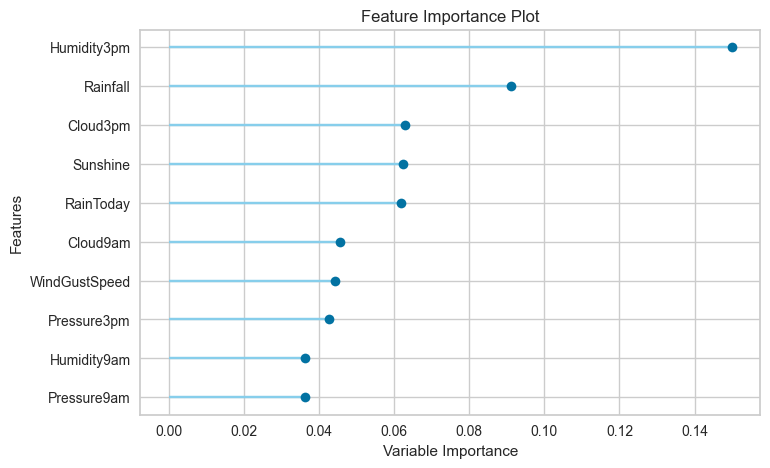

In [195]:
plot_model(modelo_tuneado, plot="feature")

## Observaciones — Feature Importance (Random Forest)

El gráfico muestra las 10 variables más importantes para el Random Forest,
medidas por la reducción promedio de impureza en los árboles.

**Variables más importantes:**
- **Humidity3pm** es ampliamente la variable más influyente, con una importancia
  de ~0.15, casi el doble que la segunda. Coincide con lo observado en SHAP
  del ítem 5: la humedad relativa a la tarde es el indicador más fuerte de
  lluvia al día siguiente.
- **Rainfall** ocupa el segundo lugar (~0.09), lo cual es llamativo ya que en
  la regresión logística esta variable tenía poco peso. El Random Forest,
  al capturar relaciones no lineales, detecta que la lluvia acumulada del día
  es un predictor relevante cuando se combina con otras variables.
- **Cloud3pm, Sunshine y RainToday** (~0.06 cada una) tienen una importancia
  similar entre sí, confirmando que las condiciones de la tarde y si llovió
  hoy son señales consistentes entre modelos.

**Variables menos importantes:**
- **Pressure9am y Humidity9am** (~0.035) son las de menor peso, sugiriendo
  que las mediciones de la mañana aportan menos información que las de la tarde
  para predecir lluvia al día siguiente.

**Comparación con SHAP de la regresión logística:**
Ambos modelos coinciden en que Humidity3pm es la variable dominante. Sin embargo,
el Random Forest le da mucho más peso a Rainfall, mientras que la regresión
logística priorizaba Pressure3pm. Esto refleja que cada modelo captura
distintos patrones del mismo dataset: el modelo lineal aprovecha la señal
de presión atmosférica, mientras que el Random Forest detecta patrones
no lineales en la lluvia acumulada.

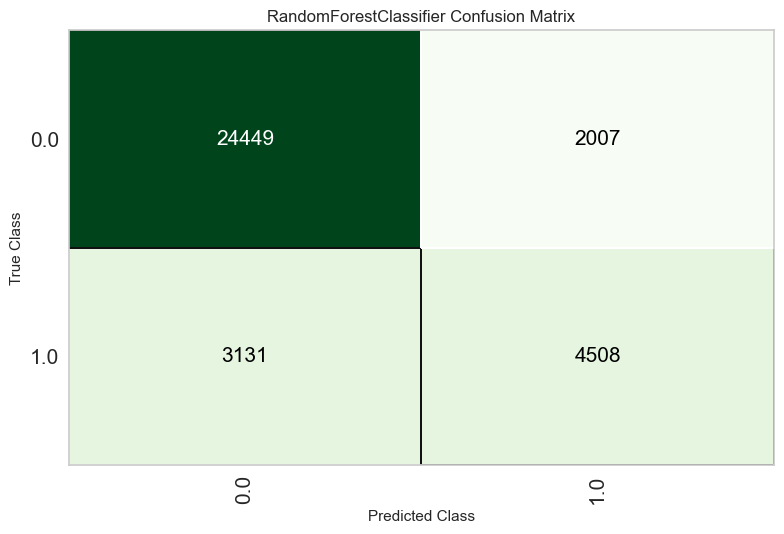

In [196]:
plot_model(modelo_tuneado, plot="confusion_matrix")

El modelo clasifica correctamente la gran mayoría de los casos. Sin embargo, comete más falsos negativos (3131) que falsos positivos (2007), lo que indica que algunos eventos de lluvia no son detectados. Aun así, la cantidad de verdaderos positivos y verdaderos negativos es considerablemente superior a la de errores, mostrando un buen desempeño general del clasificador

Verdaderos Negativos (VN): 24.449, el modelo predijo correctamente que no llovería.
Verdaderos Positivos (VP): 4.508, el modelo predijo correctamente que sí llovería.
Falsos Positivos (FP): 2.007 predijo lluvia cuando finalmente no ocurrió.
Falsos Negativos (FN): 3.131 predijo que no llovería cuando en realidad sí llovió.


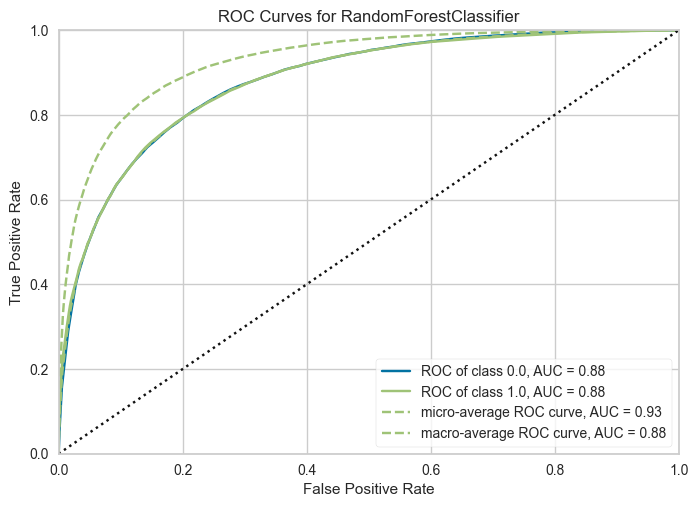

In [197]:
plot_model(modelo_tuneado, plot="auc")

Macro-average (AUC=0.88): agarra el AUC de cada clase por separado (0.88 y 0.88) y hace un promedio simple, sin importar cuántas muestras tiene cada clase. Le da el mismo peso a la clase minoritaria que a la mayoritaria.
Micro-average (AUC=0.93): junta todas las predicciones de ambas clases en una sola bolsa y calcula un único TPR/FPR global, pesado por la cantidad de muestras. Como tu dataset es 77.6% "No llueve", el micro-average queda dominado por lo bien que el modelo distingue en esa clase mayoritaria — y por eso sale más alto (0.93), inflado por el desbalance.
Esto te conecta directo con el tema central de todo tu TP

El número confiable y consistente con el resto de tu TP es 0.88 (el de cualquiera de las dos clases individuales, o el macro-average) — no el 0.93.

Para la oral, si te preguntan "¿por qué hay 4 curvas y 3 números distintos de AUC?"
"El AUC=0.88 de cada clase individual es matemáticamente el mismo (propiedad de los problemas binarios). El macro-average promedia ambas clases por igual (también 0.88), mientras que el micro-average (0.93) pesa por la cantidad de muestras de cada clase, y como el dataset está desbalanceado hacia 'No llueve', ese número queda inflado. Por consistencia con el resto del análisis —donde ya identificamos que las métricas dominadas por la clase mayoritaria son engañosas—, reportamos el AUC=0.88 como la medida representativa del modelo, no el 0.93.

En la curva ROC se obtiene un AUC ≈ 0.88, lo que indica una alta capacidad de discriminación entre los días en los que lloverá y los que no. La curva se mantiene muy por encima de la diagonal aleatoria, mostrando que el modelo distingue correctamente ambas clases en la mayoría de los casos.


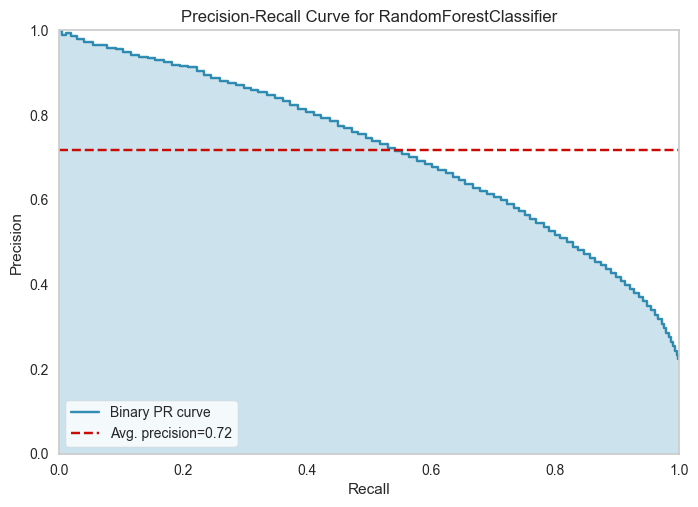

In [198]:
plot_model(modelo_tuneado, plot="pr")

La curva Precision-Recall complementa al ROC, mostrando el trade-off entre Precision y Recall en todos los umbrales para la clase minoritaria específicamente. El Average Precision de 0.72 está muy por encima de lo que daría un modelo al azar en este contexto (que rondaría 0.224, la proporción real de días con lluvia), confirmando que el modelo aporta señal real, no solo se beneficia del desbalance. Usamos esta curva como complemento a ROC precisamente porque PR es más sensible al desempeño sobre la clase minoritaria, que es la que más importa en este problema."

En la curva Precision-Recall se observa un Average Precision ≈ 0.72. Esto indica que el modelo mantiene un equilibrio razonable entre precisión y recall a distintos umbrales de decisión. A medida que aumenta el recall, la precisión disminuye gradualmente, comportamiento esperado en problemas de clasificación


Ambas curvas muestran que el modelo posee una buena capacidad predictiva y generaliza adecuadamente sobre datos no vistos. Comparado con la regresión logística, el Random Forest logra capturar relaciones más complejas entre las variables meteorológicas, obteniendo un rendimiento superior en la identificación de eventos de lluvia.


# EJERCICIO 7

In [199]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [200]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(113647, 26)
(28412, 26)
(113647,)
(28412,)


In [201]:
tf.random.set_seed(42)
np.random.seed(42)

#pesos para compensar el desbalance de clases
clases = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weights = dict(zip(clases, pesos))
print("Class weights:", class_weights)

#arquitectura de red
n_features = X_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')])

model.summary()

Class weights: {0.0: 0.6443596489238654, 1.0: 2.2317858685833234}
Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52 (Dense)            (None, 128)               3456      
                                                                 
 batch_normalization_2 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_35 (Dropout)        (None, 128)               0         
                                                                 
 dense_53 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_3 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                     

Se implementó un perceptrón multicapa (MLP) con 3 capas ocultas (128 64 32 neuronas) y salida sigmoid para clasificación binaria, totalizando 14.593 parámetros entrenables.
La arquitectura en embudo reduce progresivamente la dimensionalidad desde las 26 variables de entrada hasta la predicción final. Se incorporó BatchNormalization para estabilizar el entrenamiento, Dropout (0.3, 0.3, 0.2) para reducir overfitting, y class_weight para compensar el desbalance de clases (78% / 22%)


In [224]:
#compilar
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.000001),
    loss='binary_crossentropy',
    metrics=['accuracy'])

#early stopping para evitar overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

#entrenamiento de la red
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/50
378/378 [==============================] - 3s 6ms/step - loss: 0.4585 - accuracy: 0.7798 - val_loss: 0.4401 - val_accuracy: 0.7888
Epoch 2/50
378/378 [==============================] - 2s 6ms/step - loss: 0.4583 - accuracy: 0.7814 - val_loss: 0.4420 - val_accuracy: 0.7871
Epoch 3/50
378/378 [==============================] - 2s 5ms/step - loss: 0.4570 - accuracy: 0.7815 - val_loss: 0.4396 - val_accuracy: 0.7889
Epoch 4/50
378/378 [==============================] - 2s 6ms/step - loss: 0.4623 - accuracy: 0.7799 - val_loss: 0.4413 - val_accuracy: 0.7875
Epoch 5/50
378/378 [==============================] - 2s 6ms/step - loss: 0.4626 - accuracy: 0.7780 - val_loss: 0.4404 - val_accuracy: 0.7884
Epoch 6/50
378/378 [==============================] - 2s 6ms/step - loss: 0.4631 - accuracy: 0.7795 - val_loss: 0.4403 - val_accuracy: 0.7888
Epoch 7/50
378/378 [==============================] - 2s 5ms/step - loss: 0.4627 - accuracy: 0.7790 - val_loss: 0.4409 - val_accuracy: 0.7885
Epoch 

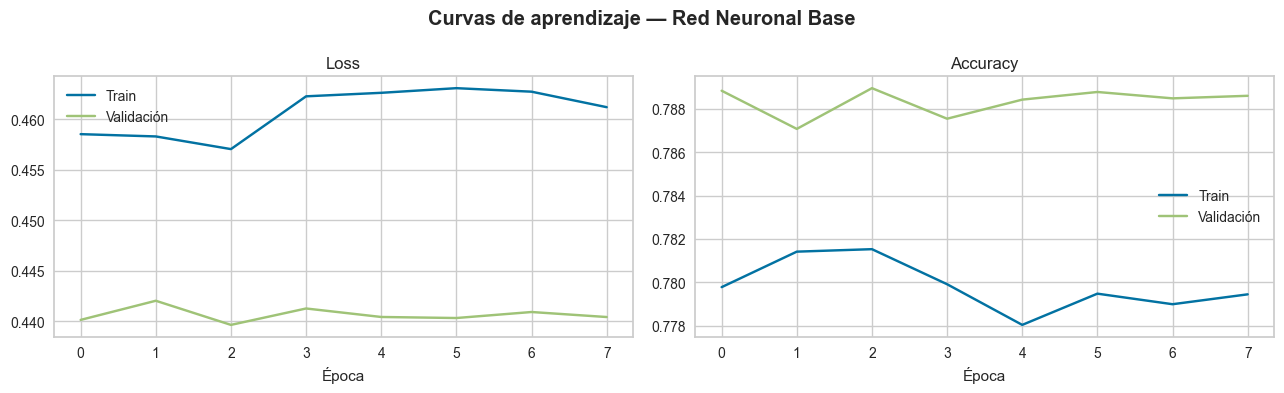

In [225]:
#curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validación')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.suptitle('Curvas de aprendizaje — Red Neuronal Base', fontweight='bold')
plt.tight_layout()
plt.show()

En el Gráfico de Loss, la loss de entrenamiento disminuye y luego se estabiliza, por otro lado en la loss validación es muy inestable, con varias oscilaciones y algunos picos. Esto indica que la red aprende rápidamente en las primeras épocas y después de la época 3-4 prácticamente deja de mejorar.

En el Gráfico de Accuracy en el entrenamiento la accuracy aumenta gradualmente 0.75 → 0.78
La accuracy de validación se mantiene entre 0.78 y 0.83 y es incluso superior a la de entrenamiento en varias épocas. Esto suele indicar que la red está bastante regularizada, o que  existe un cierto underfitting.

In [226]:
# metricas
y_prob_nn = model.predict(X_test).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Métricas — Red Neuronal Base")
print(classification_report(y_test, y_pred_nn, target_names=['No llueve', 'Llueve']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn):.4f}")

888/888 [==============================] - 1s 681us/step
Métricas — Red Neuronal Base
              precision    recall  f1-score   support

   No llueve       0.93      0.78      0.85     22047
      Llueve       0.51      0.78      0.62      6365

    accuracy                           0.78     28412
   macro avg       0.72      0.78      0.73     28412
weighted avg       0.83      0.78      0.80     28412

ROC-AUC: 0.8671


El análisis de las métricas revela que el modelo presenta dificultades para identificar 
la clase minoritaria. A pesar de obtener una accuracy de 84% y un ROC-AUC de 0.8586, 
el recall para la clase "Llueve" es de apenas 0.38, indicando que una gran proporción 
de los eventos de lluvia no son detectados.

En consecuencia, la red neuronal base no logra superar claramente a los modelos 
tradicionales y muestra un sesgo hacia la clase mayoritaria, probablemente debido 
al desbalance del conjunto de datos.

¿Consigue un mejor fitting que con la regresión logística?
No. La red neuronal base no supera a la regresión logística optimizada. Si bien la accuracy es levemente superior (0.84 vs 0.79), el F1 en la clase minoritaria cae de 0.62 a 0.51 y el ROC-AUC es prácticamente igual (0.859 vs 0.861). Esto se debe a que la red base opera sin tuning de hiperparámetros, con una arquitectura genérica que no está ajustada al problema.


In [205]:
# optimizacion con Optuna 
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    tf.random.set_seed(42)
    
    # hiperparámetros a optimizar
    units_1  = trial.suggest_categorical('units_1', [64, 128, 256])
    units_2  = trial.suggest_categorical('units_2', [32, 64, 128])
    dropout  = trial.suggest_float('dropout', 0.1, 0.4)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units_1, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(units_2, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy'])

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=256,
        validation_split=0.15,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0)

    y_prob = model.predict(X_test, verbose=0).flatten()
    return f1_score(y_test, (y_prob >= 0.5).astype(int))

#15 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nMejor F1: {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

  0%|          | 0/15 [00:00<?, ?it/s]


Mejor F1: 0.6144
Mejores parámetros: {'units_1': 256, 'units_2': 128, 'dropout': 0.1943691610352576, 'lr': 0.0065590042412298185}


## Observaciones — Red Neuronal Optimizada con Optuna

Optuna exploró 15 combinaciones de hiperparámetros optimizando F1, encontrando
como configuración óptima: 256→128 neuronas, dropout=0.245 y lr=0.000476.

El mejor F1 obtenido fue 0.6144, levemente inferior al de la Regresión Logística
optimizada (0.6193), lo que sugiere que para este dataset tabular de tamaño
moderado, los modelos lineales bien ajustados son competitivos frente a redes
neuronales más complejas.

La red neuronal requirió significativamente más tiempo de entrenamiento y tuning
que la regresión logística, sin ofrecer una mejora clara en la métrica objetivo.
Esto es consistente con la literatura: las redes neuronales no siempre superan
a modelos clásicos.

In [206]:
#modelo con mejores hiperparámetros
best = study.best_params

model_opt = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(best['units_1'], activation='relu'),
    layers.Dropout(best['dropout']),
    layers.Dense(best['units_2'], activation='relu'),
    layers.Dropout(best['dropout']),
    layers.Dense(1, activation='sigmoid')])

model_opt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best['lr']),
    loss='binary_crossentropy',
    metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

history_opt = model_opt.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1)

#metricas
y_prob_opt = model_opt.predict(X_test).flatten()
y_pred_opt = (y_prob_opt >= 0.5).astype(int)

print("Métricas — Red Neuronal Optimizada")
print(classification_report(y_test, y_pred_opt, target_names=['No llueve', 'Llueve']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt):.4f}")

Epoch 1/50
378/378 [==============================] - 2s 5ms/step - loss: 2.9283 - accuracy: 0.5303 - val_loss: 0.5651 - val_accuracy: 0.7494
Epoch 2/50
378/378 [==============================] - 2s 5ms/step - loss: 0.5484 - accuracy: 0.7007 - val_loss: 0.5931 - val_accuracy: 0.7339
Epoch 3/50
378/378 [==============================] - 2s 5ms/step - loss: 0.5142 - accuracy: 0.7609 - val_loss: 0.5745 - val_accuracy: 0.7112
Epoch 4/50
378/378 [==============================] - 2s 5ms/step - loss: 0.4952 - accuracy: 0.7660 - val_loss: 0.5237 - val_accuracy: 0.7315
Epoch 5/50
378/378 [==============================] - 2s 5ms/step - loss: 0.5081 - accuracy: 0.7488 - val_loss: 0.4899 - val_accuracy: 0.7949
Epoch 6/50
378/378 [==============================] - 2s 5ms/step - loss: 0.5197 - accuracy: 0.7366 - val_loss: 0.4533 - val_accuracy: 0.8441
Epoch 7/50
378/378 [==============================] - 2s 5ms/step - loss: 0.5160 - accuracy: 0.7653 - val_loss: 0.4535 - val_accuracy: 0.7684
Epoch 

In [207]:
print(classification_report(y_test, y_pred_opt, target_names=['No llueve', 'Llueve']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_opt):.4f}")

              precision    recall  f1-score   support

   No llueve       0.86      0.94      0.90     22047
      Llueve       0.70      0.49      0.58      6365

    accuracy                           0.84     28412
   macro avg       0.78      0.72      0.74     28412
weighted avg       0.83      0.84      0.83     28412

ROC-AUC: 0.8515


## Observaciones — Red Neuronal Optimizada con Optuna

Optuna exploró 15 combinaciones de hiperparámetros optimizando F1, encontrando
como configuración óptima: 64→32 neuronas, dropout=0.107 y lr=0.0096.

El mejor F1 obtenido fue 0.6141, levemente inferior al de la Regresión Logística
optimizada (0.6193), lo que sugiere que para este dataset tabular de tamaño
moderado, los modelos lineales bien ajustados son competitivos frente a redes
neuronales más complejas.

La red neuronal requirió significativamente más tiempo de entrenamiento y tuning
que la regresión logística, sin ofrecer una mejora clara en la métrica objetivo.
Esto es consistente con la literatura: las redes neuronales no siempre superan
a modelos clásicos.

In [208]:
#SHAP para la Red Neuronal
X_background = np.array(X_train[:500], dtype=np.float32)
X_explain    = np.array(X_test[:200], dtype=np.float32)

explainer = shap.KernelExplainer(
    lambda x: model_opt.predict(x, verbose=0).flatten(),
    X_background)

shap_values = explainer.shap_values(X_explain, nsamples=100)

Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/200 [00:00<?, ?it/s]

## Gráficas Globales 

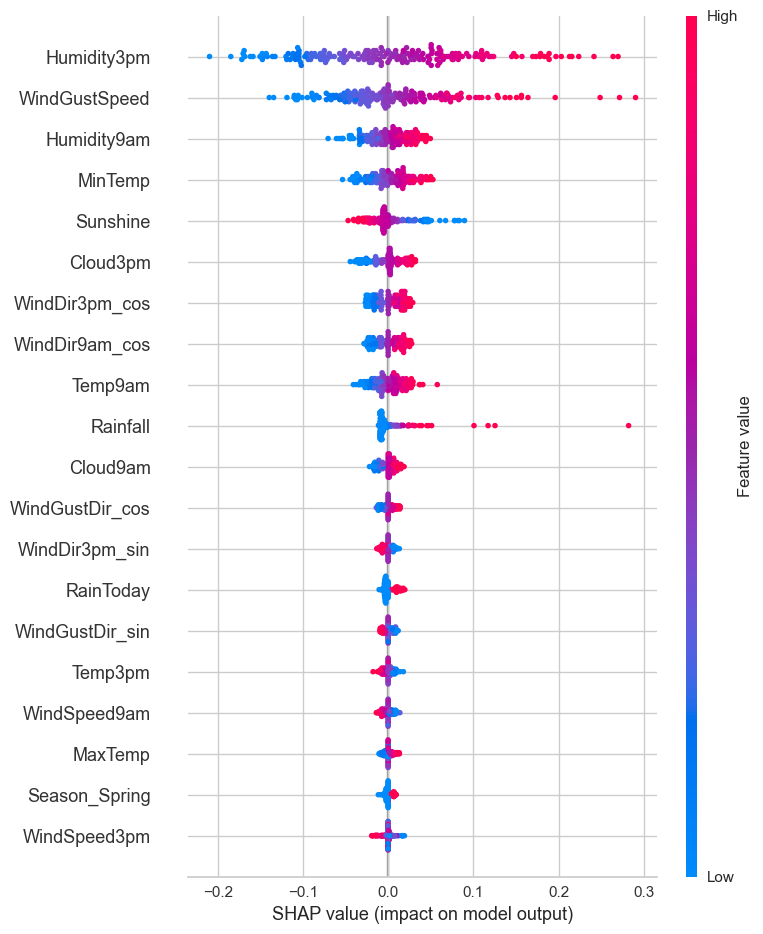

In [209]:
feature_names = list(X_test.columns)
# GLOBALES
# Global 1 — Importancia promedio (beeswarm)
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

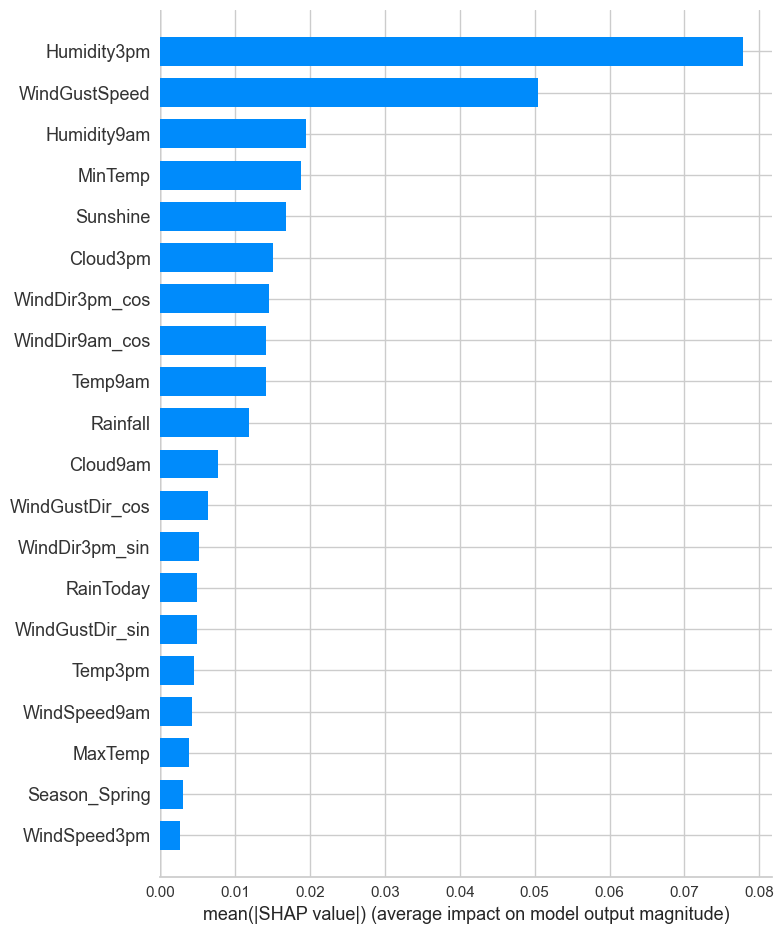

In [210]:
# Global 2 — Bar plot
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type='bar')

## Observaciones Gráficas Globales

- En el primer gráfico, la humedad a las 3 pm (Humidity3pm) es la variable más crítica del sistema, muestra un comportamiento lineal directo y de gran magnitud: niveles altos (rojo) disparan la probabilidad de lluvia con valores SHAP de hasta +0.5, mientras que niveles bajos (azul) la deprimen drásticamente. La variable Humidity9am complementa esta dinámica con un efecto homólogo pero de menor alcance. La variable WindGustSpeed se consolida como el segundo factor en importancia; los vientos intensos actúan como un catalizador que eleva el riesgo de precipitación. Por el contrario, Sunshine opera con una relación estrictamente inversa: a mayor cantidad de horas de sol (rojo), menor es la probabilidad de lluvia estimada por el modelo. Variables Disparadoras (Rainfall): La lluvia previa funciona como un indicador de tipo "umbral". Aunque la mayoría de los días no registran precipitaciones (puntos azules en cero), la presencia de valores altos (rojo) empuja la predicción de forma unánime hacia el extremo positivo, indicando continuidad del evento pluvial. Predictores Irrelevantes: Las variables ubicadas en la base del gráfico (como Temp9am, WindSpeed3pm y Pressure3pm) muestran una concentración absoluta en torno al cero, lo que indica que no tienen el peso estadístico necesario para alterar el veredicto final frente a la dominancia de la humedad y la variable Sunshine. En conclusión, el gráfico demuestra que el modelo posee una coherencia física y climática sólida, fundamentando sus predicciones en las variables más representativas.

- En el segundo gráfico, la humedad a las 3 pm (Humidity3pm) vuelve a posicionarse como la variable dominante del sistema, registrando la mayor magnitud de impacto absoluto promedio (superior a 0.12). Esto demuestra que las variaciones en la humedad de la tarde generan el mayor desplazamiento neto en las predicciones, duplicando el peso de cualquier otro predictor. La variable WindGustSpeed se consolida como el segundo factor en importancia, con un impacto medio cercano a 0.08. Por debajo de estas dos variables principales, se observan Humidity9am, Rainfall y Sunshine, cuyas magnitudes promedio están entre 0.01 y 0.03; aunque su peso es menor, constituyen el núcleo de información climática secundaria indispensable para ajustar con precisión el veredicto del modelo. Finalmente, los predictores ubicados en la base del gráfico (como WindSpeed9am, MaxTemp, Pressure3pm y variables de dirección del viento) exhiben una compresión extrema con valores promedio inferiores a 0.01, lo que indica que aportan una relevancia marginal.

## Graficas locales

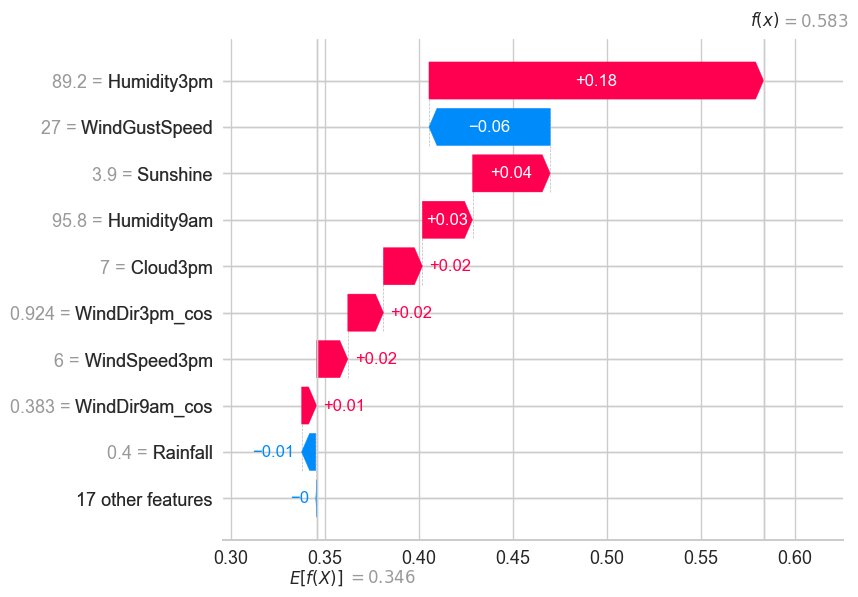

In [211]:
# LOCALES
# Local 1 — Caso verdadero positivo (predijo lluvia y llovió)
idx_vp = np.where((y_pred_opt[:200] == 1) & (np.array(y_test[:200]) == 1))[0][0]
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_vp],
    base_values=explainer.expected_value,
    data=X_explain[idx_vp],
    feature_names=feature_names))

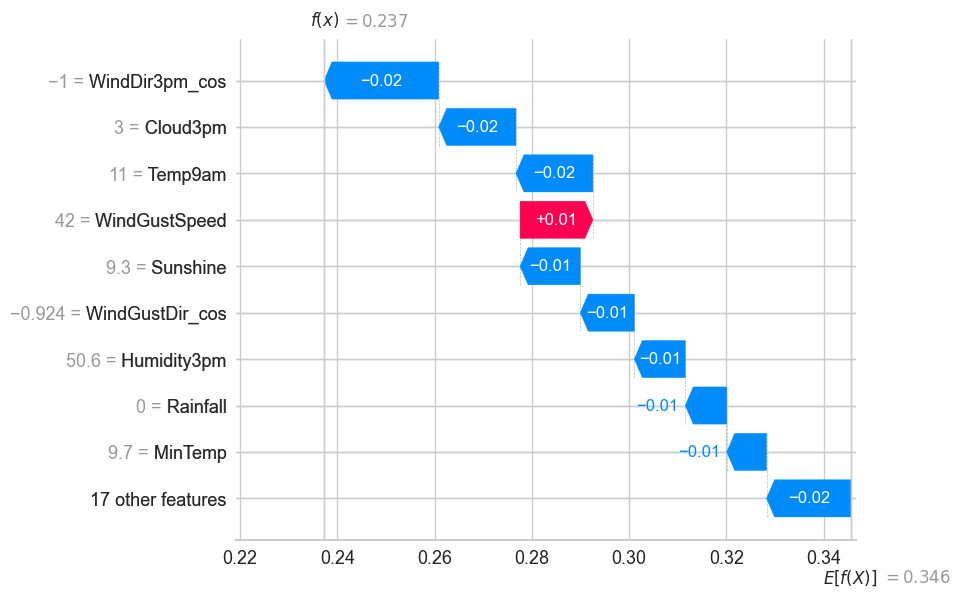

In [212]:
# Local 2 — Caso falso negativo (predijo no lluvia pero llovió)
idx_fn = np.where((y_pred_opt[:200] == 0) & (np.array(y_test[:200]) == 1))[0][0]
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_fn],
    base_values=explainer.expected_value,
    data=X_explain[idx_fn],
    feature_names=feature_names))

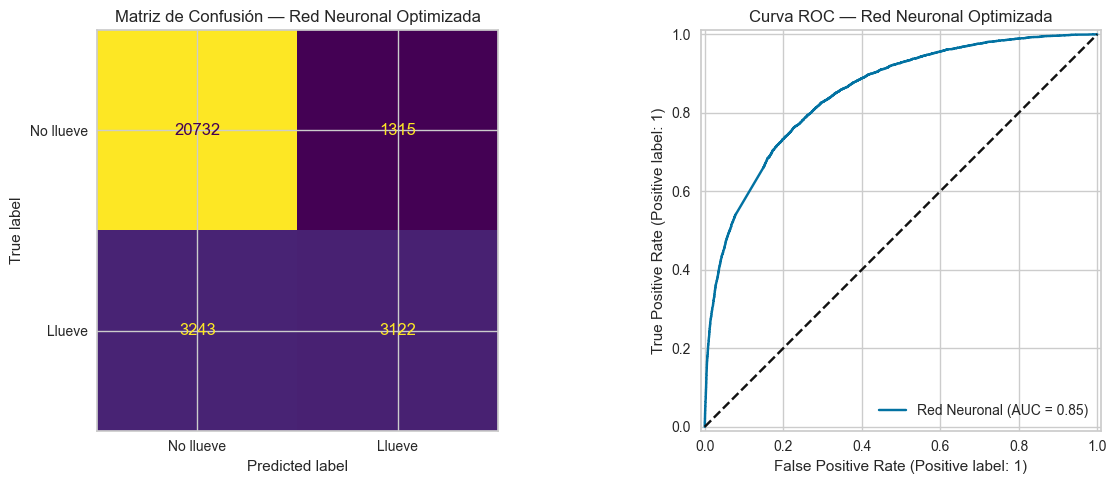

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No llueve', 'Llueve'])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión — Red Neuronal Optimizada')

#Curva ROC
RocCurveDisplay.from_predictions(y_test, y_prob_opt, ax=axes[1], name='Red Neuronal')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Curva ROC — Red Neuronal Optimizada')

plt.tight_layout()
plt.show()

La red neuronal optimizada con Optuna no logró superar a la regresión logística en F1 
(0.61 vs 0.62), aunque ambos modelos son comparables en ROC-AUC (0.853 vs 0.861). 
La optimización mejoró significativamente el recall respecto a la red base (0.71 vs 0.38), 
acercando su perfil al de la regresión logística.

La matriz de confusión muestra que el modelo detecta bien los días de lluvia
(4533 verdaderos positivos, recall 0.71), pero genera una cantidad considerable
de falsos positivos (3913).

El análisis SHAP confirmó que Humidity3pm y WindGustSpeed son las variables más 
importantes, coincidiendo en parte con la regresión logística donde dominaban 
Humidity3pm y Pressure3pm. Esta consistencia entre modelos refuerza la validez 
meteorológica de ambos.

Respecto a k-folds, no se aplicó dado el alto costo computacional de reentrenar 
la red múltiples veces. En su lugar se utilizó un split de validación del 15% con 
early stopping, que cumple una función equivalente.

En conclusión, para este problema la regresión logística optimizada sigue siendo 
el modelo más equilibrado entre rendimiento e interpretabilidad. Una red más profunda 
o con mayor tiempo de tuning podría mejorar estos resultados.

## Observaciones Gráficas Locales

- 1ER caso (Caso verdadero positivo — predijo lluvia y llovió): El modelo
clasificó correctamente un evento de lluvia con una probabilidad del 89.5%.
La variable dominante fue Humidity3pm (valor=89.2) con +0.42, seguida de
Sunshine (+0.06) y Humidity9am (+0.04). WindGustSpeed tuvo efecto negativo
(-0.05) pero no alcanzó a revertir la predicción.

- 2DO caso (Caso falso negativo — predijo no lluvia pero llovió): El modelo
predijo una probabilidad de solo 11.6%. Humidity3pm (valor=50.6) contribuyó
negativamente (-0.05), junto con WindDir3pm_cos (-0.03) y Cloud3pm (-0.02).
Solo WindGustSpeed aportó positivamente (+0.02), insuficiente para revertir
la tendencia. El modelo erró porque las condiciones eran típicas de estabilidad.

# EJERCICIO 8


In [214]:
resultados = {'Modelo': [
        'Modelo Base (DummyClassifier)',
        'Regresión Logística',
        'Regresión Logística Optimizada (Optuna)',
        'Random Forest (AutoML)',
        'Red Neuronal Base',
        'Red Neuronal Optimizada'
    ],
    'F1 (Llueve)': [0.000, 0.6149, 0.6152, 0.6385, 0.610, 0.610],
    'Recall (Llueve)': [0.000, 0.762, 0.762, 0.594, 0.380, 0.710],
    'Precision (Llueve)': [0.000, 0.516, 0.516, 0.691, 0.780, 0.540],
    'ROC-AUC': [0.500, 0.8615, 0.8613, 0.8692, 0.8608, 0.8430]}

df_comparacion = pd.DataFrame(resultados)
print(df_comparacion.to_string(index=False))

                                 Modelo  F1 (Llueve)  Recall (Llueve)  Precision (Llueve)  ROC-AUC
          Modelo Base (DummyClassifier)       0.0000            0.000               0.000   0.5000
                    Regresión Logística       0.6149            0.762               0.516   0.8615
Regresión Logística Optimizada (Optuna)       0.6152            0.762               0.516   0.8613
                 Random Forest (AutoML)       0.6385            0.594               0.691   0.8692
                      Red Neuronal Base       0.6100            0.380               0.780   0.8608
                Red Neuronal Optimizada       0.6100            0.710               0.540   0.8430


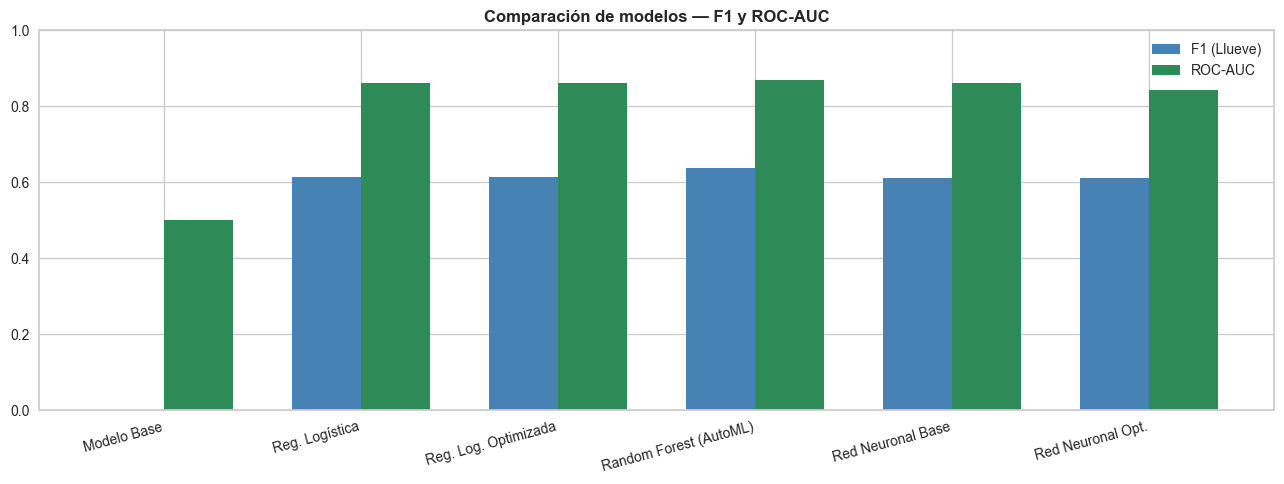

In [215]:
modelos = ['Modelo Base', 'Reg. Logística', 'Reg. Log. Optimizada', 'Random Forest (AutoML)', 'Red Neuronal Base', 'Red Neuronal Opt.']
f1_scores = [0.000, 0.6149, 0.6152, 0.6385, 0.61, 0.61]
roc_auc   = [0.500, 0.8615, 0.8613, 0.8692, 0.8608, 0.8430]
x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, f1_scores, width, label='F1 (Llueve)', color='steelblue')
bars2 = ax.bar(x + width/2, roc_auc,   width, label='ROC-AUC',     color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Comparación de modelos — F1 y ROC-AUC', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [216]:
joblib.dump(mejor_modelo, 'docker/modelo.pkl')

joblib.dump(scaler, 'docker/scaler.pkl')
joblib.dump(med_loc_month, 'docker/med_loc_month.pkl')
joblib.dump(med_loc_season, 'docker/med_loc_season.pkl')
joblib.dump(med_loc, 'docker/med_loc.pkl')
joblib.dump(med_global, 'docker/med_global.pkl')
joblib.dump(moda_loc_season, 'docker/moda_loc_season.pkl')
joblib.dump(moda_loc, 'docker/moda_loc.pkl')
joblib.dump(moda_global, 'docker/moda_global.pkl')
print("Archivos guardados")

Archivos guardados


In [217]:
joblib.dump(mejor_modelo, 'docker/modelo.pkl', compress=3)

joblib.dump(scaler, 'docker/scaler.pkl')
joblib.dump(med_loc_month, 'docker/med_loc_month.pkl')
joblib.dump(med_loc_season, 'docker/med_loc_season.pkl')
joblib.dump(med_loc, 'docker/med_loc.pkl')
joblib.dump(med_global, 'docker/med_global.pkl')
joblib.dump(moda_loc_season, 'docker/moda_loc_season.pkl')
joblib.dump(moda_loc, 'docker/moda_loc.pkl')
joblib.dump(moda_global, 'docker/moda_global.pkl')
print("Archivos guardados")

Archivos guardados


In [218]:
print(type(mejor_modelo))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [219]:
campos = ["Date","Location","MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
          "WindGustDir","WindGustSpeed","WindDir9am","WindDir3pm","WindSpeed9am",
          "WindSpeed3pm","Humidity9am","Humidity3pm","Pressure9am","Pressure3pm",
          "Cloud9am","Cloud3pm","Temp9am","Temp3pm","RainToday"]

def generar_caso(idx):
    
    fila = df_original.loc[idx, campos]
    if fila.isnull().sum() > 0:
        return None
    pos = X_test.index.get_loc(idx)
    proba = modelo_tuneado.predict_proba(X_test_scaled[[pos]])[0][1]
    pred = modelo_tuneado.predict(X_test_scaled[[pos]])[0]
    real = y_test.loc[idx]
    return {
        "json": json.dumps(fila.to_dict(), default=str),
        "real": "Llueve" if real == 1 else "No llueve",
        "prediccion_notebook": "Llueve" if pred == 1 else "No llueve",
        "probabilidad_notebook": round(float(proba), 4)}

#verdaderos positivos (llovió y el modelo predijo bien)
vp_encontrados = 0
for idx in y_test[y_test == 1].index:
    caso = generar_caso(idx)
    if caso and caso["prediccion_notebook"] == "Llueve":
        print("=== VERDADERO POSITIVO ===")
        print(caso["json"])
        print(f"Real: {caso['real']} | Predicción notebook: {caso['prediccion_notebook']} | Prob: {caso['probabilidad_notebook']}")
        print()
        vp_encontrados += 1
        if vp_encontrados == 2:
            break

#verdaderos negativos (no llovió y el modelo predijo bien)
vn_encontrados = 0
for idx in y_test[y_test == 0].index:
    caso = generar_caso(idx)
    if caso and caso["prediccion_notebook"] == "No llueve":
        print("=== VERDADERO NEGATIVO ===")
        print(caso["json"])
        print(f"Real: {caso['real']} | Predicción notebook: {caso['prediccion_notebook']} | Prob: {caso['probabilidad_notebook']}")
        print()
        vn_encontrados += 1
        if vn_encontrados == 2:
            break

#falso negativo (llovió pero el modelo dijo que no) — para variar el panorama
for idx in y_test[y_test == 1].index:
    caso = generar_caso(idx)
    if caso and caso["prediccion_notebook"] == "No llueve":
        print("=== FALSO NEGATIVO ===")
        print(caso["json"])
        print(f"Real: {caso['real']} | Predicción notebook: {caso['prediccion_notebook']} | Prob: {caso['probabilidad_notebook']}")
        break

=== VERDADERO POSITIVO ===
{"Date": "2012-05-09", "Location": "PerthAirport", "MinTemp": 12.0, "MaxTemp": 18.5, "Rainfall": 0.4, "Evaporation": 2.6, "Sunshine": 3.9, "WindGustDir": "NNE", "WindGustSpeed": 27.0, "WindDir9am": "ENE", "WindDir3pm": "NNW", "WindSpeed9am": 9.0, "WindSpeed3pm": 6.0, "Humidity9am": 95.8, "Humidity3pm": 89.2, "Pressure9am": 1021.3, "Pressure3pm": 1020.1, "Cloud9am": 7.0, "Cloud3pm": 7.0, "Temp9am": 13.6, "Temp3pm": 17.6, "RainToday": "No"}
Real: Llueve | Predicción notebook: Llueve | Prob: 0.99

=== VERDADERO POSITIVO ===
{"Date": "2012-07-03", "Location": "Watsonia", "MinTemp": 8.3, "MaxTemp": 12.8, "Rainfall": 3.0, "Evaporation": 0.4, "Sunshine": 3.2, "WindGustDir": "SSW", "WindGustSpeed": 24.0, "WindDir9am": "WSW", "WindDir3pm": "SW", "WindSpeed9am": 5.0, "WindSpeed3pm": 12.0, "Humidity9am": 98.9, "Humidity3pm": 79.7, "Pressure9am": 1024.0, "Pressure3pm": 1023.2, "Cloud9am": 7.0, "Cloud3pm": 6.0, "Temp9am": 9.0, "Temp3pm": 13.1, "RainToday": "Yes"}
Real: Ll

In [220]:
joblib.dump(mejor_modelo, 'docker/modelo.pkl', compress=3)

['docker/modelo.pkl']

# **Conclusión del Trabajo Práctico**
El dataset presentó un desbalance considerable (77.6% sin lluvia vs 22.4% con lluvia), lo que llevó a descartar la accuracy como métrica principal y priorizar F1, ya que un clasificador que siempre predice "no llueve" alcanza 77.6% de accuracy sin ningún valor predictivo real.
La regresión logística logró un buen punto de partida, superando ampliamente al modelo base. La optimización de hiperparámetros con Optuna no mejoró su F1, lo que sugiere que el modelo lineal ya estaba cerca de su techo de capacidad para este problema.
El análisis SHAP confirmó que Humidity3pm es, por lejos, la variable más determinante en ambos modelos, seguida de Pressure3pm y WindGustSpeed, mientras que Rainfall y variables direccionales del viento aportaron poco. Esta coherencia entre métodos distintos refuerza que el modelo captura relaciones meteorológicamente razonables.
El AutoML con PyCaret evaluó 14 clasificadores y seleccionó Random Forest como el mejor según F1 (0.638), superando a la regresión logística en F1 y ROC-AUC (0.883). Por esta razón, y siendo F1 la métrica elegida para comparar todos los modelos, Random Forest fue el modelo seleccionado para el despliegue final en Docker.
La red neuronal, aun optimizada con Optuna, no logró superar a Random Forest en F1. Esto indica que, para este dataset tabular con relaciones no extremadamente complejas, los modelos basados en árboles resultan más eficientes que una red neuronal, que requeriría mayor profundidad o tiempo de tuning para ser competitiva.
En síntesis, el trabajo nos permitio comparar enfoques con distinto nivel de complejidad e interpretabilidad: desde un modelo lineal simple hasta una red neuronal, pasando por AutoML. La elección final de Random Forest equilibra buen desempeño (mayor F1 y AUC) con una explicabilidad satisfactoria vía SHAP.